## universo (activos + inactivos)
Objetivo: construir universo completo 2005-2026 (activos + inactivos) y
dejarlo guardado como snapshot point-in-time en formato Parquet particionado.

Regla operativa clave:  
- No usar snapshot único 2026 para inferir 2005-2026.
- Construir panel temporal con /v3/reference/tickers?date=... (ideal mensual, mínimo trimestral).
- Filtros por corte: market=stocks, type=CS, primary_exchange IN [XNAS, XNYS, XASE, ARCX], active=true.
- Clave de entidad: FIGI (composite_figi/share_class_figi). Ticker solo como etiqueta temporal.

## Resumen General

,panel_rows,panel_snapshots,min_snapshot,max_snapshot,tickers_all_rows,qa_rows,qa_max_snapshot
0,29735570,7738,2005-01-01,2026-03-09,15979,7738,2026-03-09


## Integridad de Entidad

,metric,value
0,"dup(snapshot_date, entity_id)",0
1,"dup(snapshot_date, composite_figi) no-nulls",0
2,null_entity_id,0
3,null_composite_figi,8599151 (28.92%)
4,null_share_class_figi,8601063 (28.93%)
5,rows con fallback entity_id ticker|exchange,8599151 (28.92%)


## Estadisticas por Exchange (Ultimo Snapshot)

...

## Calidad de Atributos (Ultimo Snapshot)

,attribute,nulls,pct_null
0,cik,5256,100.00
1,list_date,5256,100.00
3,share_class_figi,1053,20.03
2,composite_figi,1052,20.02


## Cobertura Temporal (muestra)

,snapshot_date,rows,entities,with_figi,pct_with_figi
0,2005-01-01,2632,2632,1033,39.25
1,2005-01-02,2632,2632,1033,39.25
2,2005-01-03,2630,2630,1033,39.28
3,2005-01-04,2630,2630,1033,39.28
4,2005-01-05,2630,2630,1033,39.28
7733,2026-03-05,5256,5256,4204,79.98
7734,2026-03-06,5256,5256,4204,79.98
7735,2026-03-07,5256,5256,4204,79.98
7736,2026-03-08,5256,5256,4204,79.98
7737,2026-03-09,5256,5256,4204,79.98


## Graficos Inline

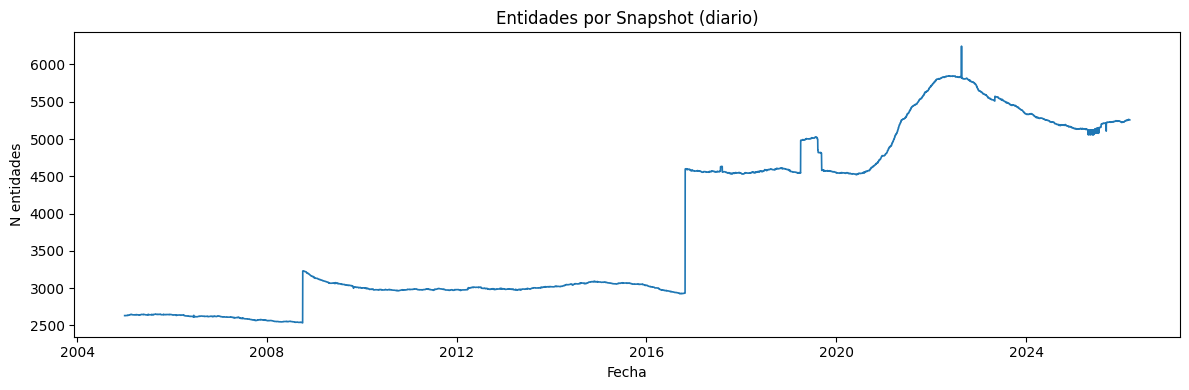

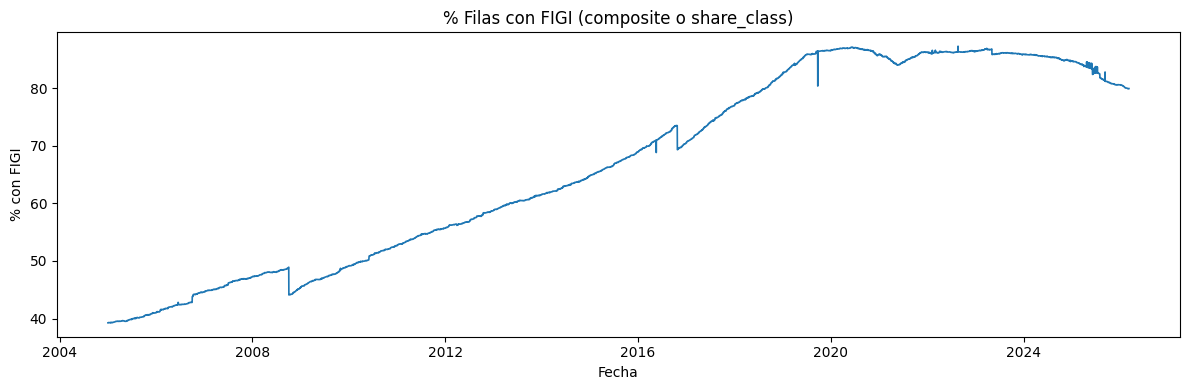

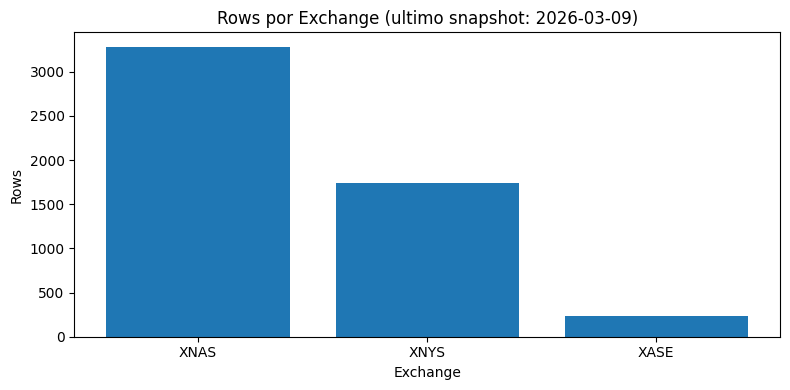

## Gate de Verificacion

,check,ok
0,panel_snapshots == qa_rows,True
1,max(panel) == max(qa),True
2,"dup(snapshot_date,entity_id) == 0",True
3,null_entity_id == 0,True


**Estado:** VALIDACION ESTRUCTURAL OK (puedes avanzar a siguiente fase).

In [ ]:
# ════════════════════════════════
# universo (activos + inactivos)
# ═══════════════════════════════
# Objetivo: construir universo completo 2005-2026 (activos + inactivos) y
# dejarlo guardado como snapshot point-in-time en formato Parquet particionado.

import runpy
runpy.run_path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\º",
    run_name="__main__"
);

**Activas vs inactivas**

In [1]:
import pandas as pd
a = pd.read_parquet(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_all.parquet")

print(a["status"].value_counts(dropna=False))
print("inactive_pct:", round((a["status"].eq("inactive").mean()*100),2), "%")

by_ex = a.groupby(["primary_exchange","status"]).size().unstack(fill_value=0)
display(by_ex)

status
inactive    10723
active       5256
Name: count, dtype: int64
inactive_pct: 67.11 %


status,active,inactive
primary_exchange,,
ARCX,0,24
XASE,235,1085
XNAS,3282,4526
XNYS,1739,5088


In [2]:
# Universo PTI - Data Contract Check (completo)
import pyarrow.dataset as ds
import pandas as pd

PANEL_PATH = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti"

dataset = ds.dataset(PANEL_PATH, format="parquet")
available = set(dataset.schema.names)

required_cols = [
    "ticker","market","locale","primary_exchange","type","active","currency_name",
    "cik","composite_figi","share_class_figi","list_date","delisted_utc",
    "last_updated_utc","snapshot_date","entity_id","exchange_priority",
    "has_composite_figi","has_share_class_figi","has_list_date"
]
cols = [c for c in required_cols if c in available]
missing_cols = sorted(set(required_cols) - set(cols))

d = dataset.to_table(columns=cols).to_pandas()

# Derivadas
d["snapshot_date"] = pd.to_datetime(d["snapshot_date"], errors="coerce")
d["snapshot_year"] = d["snapshot_date"].dt.year
d["snapshot_month"] = d["snapshot_date"].dt.month

for c in ["market","locale","primary_exchange","type","currency_name","entity_id"]:
    if c in d.columns:
        d[c] = d[c].astype("string").str.strip()

def unexpected_values(series, allowed):
    s = series.dropna()
    return sorted(set(s) - set(allowed))

results = []

# 0) Esquema
results.append(("missing_required_columns", len(missing_cols)))
results.append(("missing_required_columns_list", missing_cols))

# 1) Formato / nulos críticos
bad_snapshot = int(d["snapshot_date"].isna().sum())
bad_lastupd = int(pd.to_datetime(d["last_updated_utc"], errors="coerce", utc=True).isna().sum())
null_entity = int(d["entity_id"].isna().sum())

results += [
    ("bad_snapshot_date_parse", bad_snapshot),
    ("bad_last_updated_utc_parse", bad_lastupd),
    ("null_entity_id", null_entity),
]

# 2) Dominio esperado
allowed_ex = {"XNAS","XNYS","XASE","ARCX"}
allowed_prio = {0,1,2,3,999}

bad_market   = int((d["market"] != "stocks").sum())
bad_locale   = int((d["locale"] != "us").sum())
bad_type     = int((d["type"] != "CS").sum())
bad_exchange = int((~d["primary_exchange"].isin(list(allowed_ex))).sum())
bad_currency = int((d["currency_name"] != "usd").sum())
null_active  = int(d["active"].isna().sum())
bad_month    = int((~d["snapshot_month"].between(1,12)).sum())
bad_prio     = int((~d["exchange_priority"].isin(list(allowed_prio))).sum())
bad_year     = int((~d["snapshot_year"].between(2005, 2025)).sum())

results += [
    ("bad_market", bad_market),
    ("bad_locale", bad_locale),
    ("bad_type", bad_type),
    ("bad_exchange", bad_exchange),
    ("bad_currency_name", bad_currency),
    ("null_active", null_active),
    ("bad_snapshot_month", bad_month),
    ("bad_snapshot_year", bad_year),
    ("bad_exchange_priority", bad_prio),
]

# 3) Valores inesperados explícitos
u_market   = unexpected_values(d["market"], {"stocks"})
u_locale   = unexpected_values(d["locale"], {"us"})
u_type     = unexpected_values(d["type"], {"CS"})
u_exchange = unexpected_values(d["primary_exchange"], allowed_ex)
u_currency = unexpected_values(d["currency_name"], {"usd"})
u_prio     = unexpected_values(d["exchange_priority"], allowed_prio)

results += [
    ("unexpected_market_count", len(u_market)),
    ("unexpected_market_values", u_market[:20]),
    ("unexpected_locale_count", len(u_locale)),
    ("unexpected_locale_values", u_locale[:20]),
    ("unexpected_type_count", len(u_type)),
    ("unexpected_type_values", u_type[:20]),
    ("unexpected_exchange_count", len(u_exchange)),
    ("unexpected_exchange_values", u_exchange[:20]),
    ("unexpected_currency_count", len(u_currency)),
    ("unexpected_currency_values", u_currency[:20]),
    ("unexpected_exchange_priority_count", len(u_prio)),
    ("unexpected_exchange_priority_values", u_prio[:20]),
]

# 4) Consistencia flags vs valores
bad_flag_comp = int((d["has_composite_figi"].astype("Int64") != d["composite_figi"].notna().astype("Int64")).sum())
bad_flag_share = int((d["has_share_class_figi"].astype("Int64") != d["share_class_figi"].notna().astype("Int64")).sum())

list_date_parsed = pd.to_datetime(d["list_date"], errors="coerce")
bad_flag_list = int((d["has_list_date"].astype("Int64") != list_date_parsed.notna().astype("Int64")).sum())

results += [
    ("flag_vs_composite_mismatch", bad_flag_comp),
    ("flag_vs_share_class_mismatch", bad_flag_share),
    ("flag_vs_list_date_mismatch", bad_flag_list),
]

# 5) Duplicados clave
dup_snap_entity = int(d.duplicated(["snapshot_date","entity_id"]).sum())
tmp = d[d["composite_figi"].notna()].copy()
dup_snap_comp = int(tmp.duplicated(["snapshot_date","composite_figi"]).sum())

results += [
    ("dup_snapshot_entity", dup_snap_entity),
    ("dup_snapshot_composite_figi_nonnull", dup_snap_comp),
]

# 6) Patrones de formato (opcional fuerte)
entity_pat_figi = d["entity_id"].str.match(r"^BBG[0-9A-Z]{9,}$", na=False)
entity_pat_fallback = d["entity_id"].str.match(r"^[A-Z0-9\.\-]+\|[A-Z]{4}$", na=False)
entity_bad_pattern = int((~(entity_pat_figi | entity_pat_fallback) & d["entity_id"].notna()).sum())

cik_nonnull = d["cik"].dropna().astype("string")
cik_bad_pattern = int((~cik_nonnull.str.match(r"^\d{10}$", na=False)).sum())

delisted_nonnull = d["delisted_utc"].dropna()
delisted_bad_parse = int(pd.to_datetime(delisted_nonnull, errors="coerce", utc=True).isna().sum())

results += [
    ("entity_id_bad_pattern", entity_bad_pattern),
    ("cik_bad_pattern_nonnull", cik_bad_pattern),
    ("delisted_utc_bad_parse_nonnull", delisted_bad_parse),
]

# 7) Salida
out = pd.DataFrame(results, columns=["check","value"])
display(out)

# Resumen de checks con problema
def is_problem(v):
    if isinstance(v, (int, float)):
        return v != 0
    if isinstance(v, list):
        return len(v) > 0
    return False

issues = out[out["value"].map(is_problem)].copy()
print("\n=== ISSUES ===")
display(issues if len(issues) else pd.DataFrame({"status":["OK - sin issues"]}))

,check,value
0,missing_required_columns,0
1,missing_required_columns_list,[]
2,bad_snapshot_date_parse,0
3,bad_last_updated_utc_parse,27
4,null_entity_id,0
5,bad_market,0
6,bad_locale,0
7,bad_type,0
8,bad_exchange,0
9,bad_currency_name,0



=== ISSUES ===


,check,value
3,bad_last_updated_utc_parse,27
12,bad_snapshot_year,356426
31,entity_id_bad_pattern,2200


Buen resultado: casi todo en cero. Los 3 “issues” que salen son depurables, no necesariamente corrupción real.

  Qué significa cada uno:

  1. bad_last_updated_utc_parse = 27
     Hay 27 filas con last_updated_utc no parseable con tu regla actual.
     Puede ser formato raro o string vacío.
  2. bad_snapshot_year = 356426
     No cuadra con bad_snapshot_date_parse=0.
     Esto indica que tu regla 2005..2025 está marcando filas fuera de ese rango (probablemente 2026 o pre-2005 en algunos registros).
  3. entity_id_bad_pattern = 2200
     Tu regex de fallback es demasiado estricta. Hay tickers con caracteres especiales (/, ^, etc.) y quedan marcados como “bad” aunque
     sean válidos.



**last_updated_utc no parseables**

**bad_last_updated_utc_parse = 27**  
No parece corrupción masiva. Son 27 strings raros (espacios, vacíos, formato extraño).  
Hay que listar exactamente cuáles son.

Porque el `mask` se calculó sobre valores que pandas no pudo parsear en ese momento (27 filas), pero al mostrar la tabla el valor
“visible” puede parecer normal.

Suele pasar por caracteres invisibles o tipo mixto. Verifícalo así:

In [3]:
s = d["last_updated_utc"].astype("string")
mask = pd.to_datetime(s, errors="coerce", utc=True).isna()

dbg = d.loc[mask, ["last_updated_utc","ticker","snapshot_date"]].copy()
dbg["repr"] = s[mask].map(repr)
dbg["len"] = s[mask].str.len()
display(dbg.head(30))

,last_updated_utc,ticker,snapshot_date,repr,len
4379409,2025-01-16T17:36:25Z,KRC,2009-03-19,'2025-01-16T17:36:25Z',20
4381124,2025-01-16T17:36:25Z,IRF,2009-03-19,'2025-01-16T17:36:25Z',20
4381977,2025-01-16T17:36:25Z,WX,2009-03-19,'2025-01-16T17:36:25Z',20
6175282,2025-01-15T22:47:46Z,AGM,2011-10-06,'2025-01-15T22:47:46Z',20
6176243,2025-01-15T22:47:46Z,HEK,2011-10-06,'2025-01-15T22:47:46Z',20
6176805,2025-01-15T22:47:46Z,SEH,2011-10-06,'2025-01-15T22:47:46Z',20
7576073,2025-01-15T22:45:43Z,IQI,2012-02-19,'2025-01-15T22:45:43Z',20
7576807,2025-01-15T22:45:43Z,ELY,2012-02-19,'2025-01-15T22:45:43Z',20
12096626,2025-01-15T22:34:10Z,WYN,2016-02-15,'2025-01-15T22:34:10Z',20
15676907,2024-12-03T20:52:57Z,FISV,2018-06-29,'2024-12-03T20:52:57Z',20


**bad_snapshot_year = 356426 con año 2026**  
Esto no es “malo” si tu objetivo es 2005-2026.  
Tu check estaba puesto a 2005..2025, por eso marca todo 2026 como error.  

In [4]:
# 2) años fuera de rango
yr = d["snapshot_year"]
bad_year_rows = d[~yr.between(2005, 2026)][["snapshot_date","ticker","entity_id"]]
print("bad_year_counts:")
print(bad_year_rows["snapshot_date"].dt.year.value_counts().sort_index())
display(bad_year_rows.head(30))

bad_year_counts:
Series([], Name: count, dtype: int64)


,snapshot_date,ticker,entity_id


**entity_id_bad_pattern = 2200**  
Tu regex era demasiado estricta.   
IDs como IMHpC|XNYS, NVLw|XNYS son fallback válidos (tienen minúsculas/sufijos raros).  

In [5]:
# 3) entity_id "bad" según regex actual
pat_figi = d["entity_id"].str.match(r"^BBG[0-9A-Z]{9,}$", na=False)
pat_fallback = d["entity_id"].str.match(r"^[A-Z0-9\.\-]+\|[A-Z]{4}$", na=False)
bad_eid = d[~(pat_figi | pat_fallback) & d["entity_id"].notna()][["entity_id","ticker","primary_exchange"]]
display(bad_eid.head(50))

,entity_id,ticker,primary_exchange
1717,IMHpC|XNYS,IMHpC,XNYS
4349,IMHpC|XNYS,IMHpC,XNYS
6979,IMHpC|XNYS,IMHpC,XNYS
9609,IMHpC|XNYS,IMHpC,XNYS
12239,IMHpC|XNYS,IMHpC,XNYS
14869,IMHpC|XNYS,IMHpC,XNYS
15225,NVLw|XNYS,NVLw,XNYS
17501,IMHpC|XNYS,IMHpC,XNYS
17857,NVLw|XNYS,NVLw,XNYS
20133,IMHpC|XNYS,IMHpC,XNYS


**Resultado de los tres**

1. bad_last_updated_utc_parse = 27

- Hallazgo: falso positivo de parseo (timestamps válidos ISO, p.ej. 2025-01-16T17:36:25Z).
- Causa: parseo con inferencia/formato mixto en pandas.
- Solución: parsear con format="ISO8601" (o format="mixed") + str.strip().

2. bad_snapshot_year = 356426 (inicial)

- Hallazgo: eran filas de 2026, no datos corruptos.
- Causa: check estaba configurado a rango 2005..2025.
- Solución: ajustar contrato al objetivo real 2005..2026. Resultado actual: bad_snapshot_year = 0.

3. entity_id_bad_pattern = 2200 (inicial)

- Hallazgo: falso positivo por regex demasiado estricta para fallback ticker|exchange.
- Causa: había tickers válidos con caracteres/casos no contemplados (IMHpC|XNYS, NVLw|XNYS).
- Solución: regex fallback más permisiva (^[^|]+\|[A-Z]{4}$). Resultado actual: entity_id_bad_pattern = 0.

**Refactory en test check ajustando los hallazgos**

In [6]:
# Lanzadera terminal:
#
#  python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\check_universe_pti_contract.py --panel-path C:
#  \TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti --year-min 2005 --year-max 2026


# Contract check (sintético)
# Script: check_universe_pti_contract.py
#
# Qué revisa y cómo:
# 1) Esquema:
#    - Verifica columnas requeridas y reporta faltantes.
#
# 2) Formato/nulos críticos:
#    - snapshot_date parseable (pd.to_datetime, errors="coerce").
#    - last_updated_utc parseable en UTC (parse robusto ISO8601/mixed + strip).
#    - entity_id no nulo.
#
# 3) Dominio de valores esperados:
#    - market == "stocks"
#    - locale == "us"
#    - type == "CS"
#    - primary_exchange IN {XNAS, XNYS, XASE, ARCX}
#    - currency_name == "usd"
#    - active no nulo
#    - snapshot_month entre 1..12 (derivado de snapshot_date)
#    - snapshot_year entre [year_min, year_max] (default 2005..2026)
#    - exchange_priority IN {0,1,2,3,999}
#
# 4) Valores inesperados explícitos:
#    - Lista y cuenta valores fuera del dominio para:
#      market, locale, type, primary_exchange, currency_name, exchange_priority.
#
# 5) Consistencia de flags:
#    - has_composite_figi == notna(composite_figi)
#    - has_share_class_figi == notna(share_class_figi)
#    - has_list_date == notna(list_date parseado)
#
# 6) Duplicados:
#    - dup(snapshot_date, entity_id) == 0
#    - dup(snapshot_date, composite_figi) en no nulos == 0
#
# 7) Patrones de formato:
#    - entity_id válido si:
#      a) FIGI: ^BBG[0-9A-Z]{9,}$, o
#      b) fallback: ^[^|]+\|[A-Z]{4}$
#    - cik no nulo con patrón ^\d{10}$
#    - delisted_utc no nulo parseable UTC.
#
# Salida:
# - Tabla completa de checks (check, value).
# - Tabla ISSUES con solo checks != 0 o listas no vacías.

import runpy

_ = runpy.run_path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\check_universe_pti_contract.py",
    run_name="__main__"
)

,check,value
0,missing_required_columns,0
1,missing_required_columns_list,[]
2,bad_snapshot_date_parse,0
3,bad_last_updated_utc_parse,0
4,null_entity_id,0
5,bad_market,0
6,bad_locale,0
7,bad_type,0
8,bad_exchange,0
9,bad_currency_name,0



=== ISSUES ===


,status
0,OK - sin issues


**Miramos duplicados**

Para mirar duplicados,  
Construyo una clave FIGI por fila
  - figi = composite_figi y si falta uso share_class_figi.

si no existe:

  - con FIGI: dedup por snapshot_date + figi
  - sin FIGI: dedup por snapshot_date + ticker|exchange (proxy)

In [7]:
# Si dup(snapshot_date, figi) = 0, la regla está cumpliéndose.
# Si sale >0, ahí tienes en conf los casos a revisar.

import pyarrow.dataset as ds
import pandas as pd

p = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti"
d = ds.dataset(p, format="parquet").to_table(
    columns=["snapshot_date","ticker","composite_figi","share_class_figi","entity_id"]
).to_pandas()

d["snapshot_date"] = pd.to_datetime(d["snapshot_date"]).dt.date
d["figi"] = d["composite_figi"].fillna(d["share_class_figi"])

# 1) Duplicados por (snapshot_date, figi) solo donde hay FIGI
with_figi = d[d["figi"].notna()].copy()
dup_figi = with_figi.duplicated(["snapshot_date","figi"]).sum()

# 2) Duplicados por (snapshot_date, ticker) para comparar
dup_ticker = d.duplicated(["snapshot_date","ticker"]).sum()

print("dup(snapshot_date, figi) [figi no nulo]:", int(dup_figi))
print("dup(snapshot_date, ticker):", int(dup_ticker))

# 3) Muestra de conflictos FIGI (si existen)
conf = with_figi[with_figi.duplicated(["snapshot_date","figi"], keep=False)] \
    .sort_values(["snapshot_date","figi","ticker"])
display(conf.head(50))

dup(snapshot_date, figi) [figi no nulo]: 0
dup(snapshot_date, ticker): 0


,snapshot_date,ticker,composite_figi,share_class_figi,entity_id,figi


# Universo Filtrado listed - deslisted

Añadimos fechas de listado y deslistado:

1. **first_seen_date**: desde cuándo aparece en el panel.
2. **last_seen_date**: hasta cuándo aparece en el panel.

Eso te dice “cuándo estuvo listada/visible en tu universo PTI”.  
No siempre coincide con fecha oficial de IPO/desliste (list_date/delisted_utc) porque esos campos pueden venir vacíos.

Script creado:

- `build_tickers_2005_2026.py`

Qué hace:

1. Lee tickers_all.parquet.
2. Aplica regla de intersección temporal:  
    `[first_seen_date, last_seen_date] ∩ [2005-01-01, 2026-12-31] != vacío`  
3. Guarda tickers_2005_2026.parquet.

In [1]:
'''bash
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\build_tickers_2005_2026.py
'''

import runpy
_ = runpy.run_path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\build_tickers_2005_2026.py",
    run_name="__main__"
)

input_rows=15,979
output_rows=15,979
window=2005-01-01..2026-12-31
saved=C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet


In [2]:
import pandas as pd
p = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet"
d = pd.read_parquet(p)
print("rows:", len(d))
print(d.tail(1).T)

rows: 15979
                                            15978
ticker                                         ZZ
name                        SEALY CORPORATION COM
market                                     stocks
locale                                         us
primary_exchange                             XNYS
type                                           CS
active                                       True
currency_name                                 usd
cik                                    0000748015
composite_figi                                NaN
share_class_figi                              NaN
list_date                                    None
delisted_utc                                 None
last_updated_utc      2025-01-15T22:43:12.193858Z
snapshot_date                          2013-03-18
entity_id                                 ZZ|XNYS
exchange_priority                               1
has_composite_figi                              0
has_share_class_figi                  

**ticker**: `AAA`.  
**name**: `ALTANA AKTIENGESELLSCHAFT SPON ADR`.  
**market**: `stocks`.  
**locale**: `us`.  
**primary_exchange**: `XNYS`.  
**type**: `CS`.  
**active**: `True` en su última observación (`snapshot_date=2007-05-21`).  
**currency_name**: `usd`.  
**cik**: `NaN` (no informado).  
**composite_figi**: `NaN` (no informado).  
**share_class_figi**: `NaN` (no informado).  
**list_date**: `None` (sin fecha/hora reportada).  
**delisted_utc**: `None` (sin fecha/hora de desliste reportada).  
**last_updated_utc**: `2025-01-16T17:30:52.609805Z`.  
**snapshot_date**: `2007-05-21` (último corte PTI donde aparece).  
**entity_id**: `AAA|XNYS` (fallback por ausencia de FIGI).  
**exchange_priority**: `1` (prioridad interna para `XNYS`).  
**has_composite_figi**: `0` (coherente con `composite_figi` vacío).  
**has_share_class_figi**: `0` (coherente con `share_class_figi` vacío).    
**has_list_date**: `0` (coherente con `list_date` vacío).    
**cut_frequency**: `daily`.    
**first_seen_date**: `2005-01-01`.  primera fecha en que la entidad aparece en el panel   
**last_seen_date**: `2007-05-21`.  última fecha en que la entidad aparece en el panel  
**latest_active**: `True` en esa última observación, el flag `active` era `True`   
**status_confidence**: `high`.  clasificación operativa con confianza   
**status**: `inactive` (no aparece en el último snapshot global del panel).    


--- 


**active**: Flag de “activo” reportado por Polygon en ese `snapshot_date` (no es el estado final del panel).  
**composite_figi**: FIGI compuesto del instrumento (identificador externo); puede venir nulo.  
**share_class_figi**: FIGI de clase de acción; puede venir nulo.  
**list_date**: Fecha oficial de listado reportada por Polygon; puede faltar (`None`/`null`).  
**delisted_utc**: Fecha/hora oficial de desliste reportada por Polygon; puede faltar (`None`/`null`).  
**last_updated_utc**: Timestamp UTC de última actualización del registro en Polygon (metadato del proveedor).  
**snapshot_date**: Fecha del corte point-in-time usada para construir ese registro del panel.  
**entity_id**: Clave operativa de entidad; prioriza FIGI y usa fallback `ticker|exchange` si no hay FIGI.  
**first_seen_date**: Primera `snapshot_date` en que esa `entity_id` aparece en el panel construido.  
**last_seen_date**: Última `snapshot_date` en que esa `entity_id` aparece en el panel construido.  
**latest_active**: Valor de `active` en la última fila disponible de esa `entity_id` (última observación propia).  
**status_confidence**: Nivel de confianza operativo del `status` final (`high`/`medium`/`low`, según cobertura/cortes).  
**status**: Estado operativo final en el panel (`active`/`inactive`) según aparición en el último snapshot global. 

## Universo Híbrido Enriquecido (Market Cap, Description, Employees, SIC Code, Delisted UTC)  

Enriquecer el universo filtrado con estrategia dual y prioridad temporal (as-of date).  

Estrategia Dual de Enriquecimiento:
- ACTIVOS (por corte):
- /v3/reference/tickers/{ticker}?date=...
- market_cap, weighted_shares_outstanding, description, employees, sic, etc.
- INACTIVOS o faltantes:
- algunos inactivos pueden no resolver; usar backfill desde snapshots/eventos.
- delisted_utc, list_date, cik, figi.

Merge final:
- prioridad dato as-of-date > dato estático de snapshot final.


Confirmado en docs oficiales (Massive/Polygon):

1. GET /v3/reference/tickers (All Tickers) es endpoint PTI base para universo por fecha (date) y filtros (market, type, active, etc.).
2. GET /v3/reference/tickers/{ticker} (Ticker Overview) soporta date y expone campos de enriquecimiento (market_cap,
    weighted_shares_outstanding, sic_code, total_employees, list_date, identificadores, etc.).
3. Delisted no se elimina del histórico (KB oficial: sin survivorship bias).
4. GET /vX/reference/tickers/{id}/events existe (experimental) para continuidad de identidad/cambios ticker.
5. Catálogos oficiales para validar filtros: ticker types y exchanges.

Fuentes:

- All Tickers: https://polygon.io/docs/rest/stocks/tickers/all-tickers
- Ticker Overview: https://polygon.io/docs/rest/stocks/tickers/ticker-overview
- Ticker Events: https://polygon.io/docs/rest/stocks/corporate-actions/ticker-events
- Ticker Types: https://polygon.io/docs/rest/stocks/tickers/ticker-types
- Exchanges: https://polygon.io/docs/rest/stocks/market-operations/exchanges
- Delisted KB: https://polygon.io/knowledge-base/article/what-does-polygon-do-with-delisted-tickers
- Ticker changes KB: https://polygon.io/knowledge-base/article/how-does-polygon-handle-ticker-changes-andacquisitions

```BASH
# launcher
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\build_universe_hybrid_enriched.py 
   --input C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet 
   --outdir C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched 
   --batch-size 200 
   --resume


rows=15,979
saved=C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched.parquet
qa=C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched.qa.csv
coverage:
                               field  non_null  rows  coverage_pct
                     final_round_lot     15978 15979         99.99
                   final_ticker_root     15978 15979         99.99
final_share_class_shares_outstanding     15245 15979         95.41
                           final_cik     14936 15979         93.47
                  final_phone_number     11643 15979         72.86
              final_address_address1     11641 15979         72.85
                  final_address_city     11641 15979         72.85
           final_address_postal_code     11572 15979         72.42
                 final_address_state     11556 15979         72.32
                      final_sic_code     11528 15979         72.14
                     final_list_date     10643 15979         66.61
   final_weighted_shares_outstanding     10495 15979         65.68
                    final_market_cap     10454 15979         65.42
                final_composite_figi      9128 15979         57.12
              final_share_class_figi      9121 15979         57.08
                   final_description      8896 15979         55.67
                  final_homepage_url      8489 15979         53.13
               final_total_employees      7598 15979         47.55
             final_branding_logo_url      5656 15979         35.40
             final_branding_icon_url      4173 15979         26.12
                 final_ticker_suffix       734 15979          4.59
                  final_delisted_utc         0 15979          0.00
```


# Verificación: UNIVERSO HÍBRIDO ENRIQUECIDO


In [3]:
import pandas as pd; 

p=r'C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\checkpoints\batch_0002000_0002199.parquet'; 
d=pd.read_parquet(p); 
print(d.head(1).T)

                                                                                0
row_id                                                                       2000
http_status                                                                   200
request_ticker                                                               PTGI
request_date                                                           2013-11-28
asof_found                                                                   True
asof_error                                                                   None
asof_active                                                                  True
asof_name                                    PTGI HOLDINGS INC. COMMON STOCK (DE)
asof_market_cap                                                               NaN
asof_weighted_shares_outstanding                                              NaN
asof_share_class_shares_outstanding                                    14219000.0
asof_total_emplo

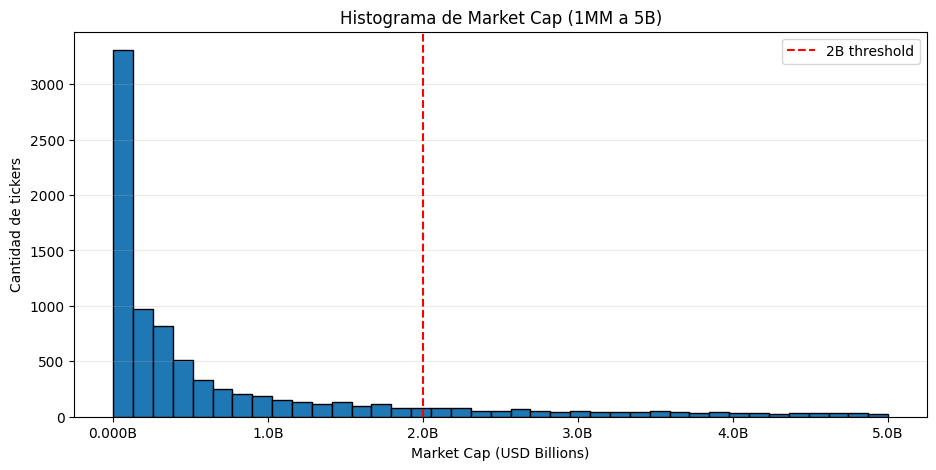

tickers en [1MM,5B]: 8537


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

p = r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched.parquet"
d = pd.read_parquet(p)

mc = pd.to_numeric(d["final_market_cap"], errors="coerce")
mc = mc[(mc.notna()) & (mc > 0)] / 1e9  # billions

# 1 millón a 5 billones => 0.001B a 5B
w = mc[(mc >= 0.001) & (mc <= 5)]

bins = np.linspace(0.001, 5, 40)
counts, edges = np.histogram(w, bins=bins)

plt.figure(figsize=(11,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), align="edge", edgecolor="black")
plt.axvline(2, color="red", linestyle="--", linewidth=1.5, label="2B threshold")
plt.xlabel("Market Cap (USD Billions)")
plt.ylabel("Cantidad de tickers")
plt.title("Histograma de Market Cap (1MM a 5B)")
plt.grid(axis="y", alpha=0.25)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.3f}B" if x < 1 else f"{x:.1f}B"))
plt.legend()
plt.show()

print("tickers en [1MM,5B]:", len(w))

# implementamos deslistados directamente desde polygon : final_delisted_utc 67.11%

**universe_hybrid_enriched.parquet**

1. Catálogo de inactivos directo desde Polygon:
   - /v3/reference/tickers con active=false, type=CS, exchanges XNAS/XNYS/XASE/ARCX.
   - Se guarda en: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\inactive_catalog.parquet
2. Merge del catálogo en el híbrido por ticker + primary_exchange.
3. Prioridad de fuentes actualizada:
   - asof > inactive_catalog > events > fallback > missing
   - para final_delisted_utc, final_cik, final_composite_figi, final_share_class_figi, final_last_updated_utc.
4. Inferencia final para delisted:
   - si sigue nulo y status=inactive, usa last_seen_date como final_delisted_utc.
   - marca source_final_delisted_utc = inferred_last_seen.

Nuevos flags:
   - --disable-inactive-catalog
   - --inactive-catalog-refresh

```BASH
# ejecuto  (forzando refresco del catálogo):
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\build_universe_hybrid_enriched.py 
   --input C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet 
   --outdir C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched 
   --batch-size 200 
   --inactive-catalog-refresh 
   --resume

      saved=C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched.parquet
      qa=C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched.qa.csv
      
      coverage:

                                 field  non_null  rows  coverage_pct
                        final_round_lot     15978 15979         99.99
                      final_ticker_root     15978 15979         99.99
                              final_cik     15385 15979         96.28
   final_share_class_shares_outstanding     15245 15979         95.41
                     final_phone_number     11643 15979         72.86
                 final_address_address1     11641 15979         72.85
                     final_address_city     11641 15979         72.85
              final_address_postal_code     11572 15979         72.42
                    final_address_state     11556 15979         72.32
                         final_sic_code     11528 15979         72.14
                     final_delisted_utc     10724 15979         67.11
                        final_list_date     10643 15979         66.61
      final_weighted_shares_outstanding     10495 15979         65.68
                       final_market_cap     10454 15979         65.42
                   final_composite_figi      9623 15979         60.22
                 final_share_class_figi      9616 15979         60.18
                      final_description      8896 15979         55.67
                     final_homepage_url      8489 15979         53.13
                  final_total_employees      7598 15979         47.55
                final_branding_logo_url      5656 15979         35.40
                final_branding_icon_url      4173 15979         26.12
                    final_ticker_suffix       734 15979          4.59


```

****descargaste 21 campos “objetivo”, pero además guardaste todo el contexto para auditoría/reproducibilidad.****


In [10]:
# Ejemplo de ticker con data descargada en la última corrida (hybrid_enriched)
from pathlib import Path
import pandas as pd
from IPython.display import display

P = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched.parquet")
d = pd.read_parquet(P)

cand = d[
    d["final_market_cap"].notna() &
    d["final_weighted_shares_outstanding"].notna() &
    d["final_description"].notna()
].copy()

if len(cand) == 0:
    cand = d.copy()

row = cand.iloc[[0]].T.rename(columns={cand.index[0]: "value"})

print("ticker elegido:", cand.iloc[0]["ticker"])
print("snapshot_date:", cand.iloc[0]["snapshot_date"])
print("status:", cand.iloc[0]["status"])

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", 1000
):
    display(row)


ticker elegido: A
snapshot_date: 2022-02-08
status: inactive


,value
ticker,A
name,Agilent Technologies Inc.
market,stocks
locale,us
primary_exchange,XNYS
type,CS
active,True
currency_name,usd
cik,0001090872
composite_figi,BBG000BWQYZ5


## Filtro Small Caps Target Population (< $2B) con Anti-Survivorship Bias

Definir small-cap en forma point-in-time (sin look-ahead bias).

Regla por fecha t:
- market_cap_t = close_t * shares_outstanding_t
- close_t viene de day_aggs_v1
- small_cap_t = market_cap_t < 2_000_000_000

Fallback obligatorio si falta shares_outstanding_t:
- usar último valor válido anterior (LOCF) con límite máximo de antigüedad (ejemplo: 180 días).
- si no hay valor dentro del límite: market_cap_t = null e is_small_cap_t = null.
- nunca imputar con datos futuros.

Notas críticas:
- No clasificar 2005-2026 con market_cap "actual".
- Mantener inactivos históricos que fueron small-cap en su ventana de vida.
- Guardar tabla final:
- population_target_pti(date, figi, ticker, is_small_cap, exchange, status).

**Problema real y solucion --> Necesitamos datos de los fundamentales.**

## Descarga end points fundamentales por tiker

**outdir D:\financial**

```bash
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\download_fundamentals_v1.py 
   --input C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet 
   --outdir D:\financial --datasets income_statements,balance_sheets,cash_flow_statements,ratios 
   --batch-size 200 
   --workers 12 
   --limit 1000 
   --max-pages 50 
   --resume 
   --resume-validate 
   --progress-every 25

tickers_processed=12,473
tickers_skipped_valid=0
outdir=D:\financial
progress=D:\financial\_run\download_fundamentals_v1.progress.json
errors=D:\financial\_run\download_fundamentals_v1.errors.csv
```

In [ ]:
# cargo ejemplo de un file en cada end point descargado
import pandas as pd
from pathlib import Path
from IPython.display import display

PATHS = {
    "balance_sheets": Path(r"D:\financial\balance_sheets\ticker=A\balance_sheets_A.parquet"),
    "cash_flow_statements": Path(r"D:\financial\cash_flow_statements\ticker=A\cash_flow_statements_A.parquet"),
    "income_statements": Path(r"D:\financial\income_statements\ticker=A\income_statements_A.parquet"),
    "ratios": Path(r"D:\financial\ratios\ticker=A\ratios_A.parquet"),
}

## Auditoria de la descarga 

`C:\Users\AlexJ\financial_audit`

```BASH
# Lanzadera terminal:
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\01_data_fundamentals\cell_code\audit_fundamentals_download.py --input-universe C:
\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet --outdir D:\financial --datasets
income_statements,balance_sheets,cash_flow_statements,ratios --limit 1000 --max-pages 50
```

Outputs:

- D:\financial\_audit\audit_summary.json
- D:\financial\_audit\coverage_by_endpoint.csv
- D:\financial\_audit\missing_tickers_by_endpoint.csv
- D:\financial\_audit\file_level_audit.csv
- D:\financial\_audit\date_ranges_by_ticker_endpoint.csv
- D:\financial\_audit\severe_issues.csv

1. Cobertura por dataset

- expected_tickers vs downloaded_tickers
- missing_tickers, extra_tickers
- tickers_with_multiple_files

2. Integridad de archivo por ticker+dataset

- archivo legible (read_ok)
- rows_total, rows_business (excluyendo _empty=True)
- ticker canónico correcto (ticker_col_ok)
- mismatches en campo tickers (tickers_col_mismatch_rows)
- unicidad de cik (cik_nunique)
- columna _dataset consistente (dataset_col_ok)
- parseo de _ingested_utc (ingested_utc_parseable)
- columnas mínimas requeridas (missing_required_cols)
- señal de truncado por paginación (rows_hit_page_cap vía limit*max_pages)

3. Rango temporal por archivo

- detecta columna de fecha usada (date_col_used)
- calcula date_start, date_end por archivo

4. Validación temporal por ticker (global)

- consolida fin_min_date / fin_max_date (todos los datasets)
- construye ventana de referencia:
    - prioridad lifecycle oficial (official_list_date, official_delist_date)
    - fallback PTI (first_seen_date, last_seen_date)
- compara con tolerancias (--tolerance-pre-days, --tolerance-post-days)
- etiqueta estado por ticker:
    - OK
    - NO_DATA
    - ANOMALY_PRE_START
    - ANOMALY_POST_END
    - UNKNOWN_WINDOW

5. Reportes que genera

- coverage_by_endpoint.csv
- missing_tickers_by_endpoint.csv
- file_level_audit.csv
- date_ranges_by_ticker_endpoint.csv
- severe_issues.csv
- temporal_validation_by_ticker.csv
- temporal_issues.csv
- audit_summary.json

In [12]:
import pandas as pd
from pathlib import Path

# Auditoría global
p_audit = Path(r"C:\Users\AlexJ\financial_audit\file_level_audit.csv")
d = pd.read_csv(p_audit)

# Archivo ejemplo endpoint income_statements
p_income = Path(r"D:\financial\income_statements\ticker=A\income_statements_A.parquet")
df = pd.read_parquet(p_income)

def print_dataset_report(df_audit: pd.DataFrame, ds: str):
    g = df_audit[df_audit["dataset"] == ds].copy()
    print(f"\n=== {ds} ===")
    print("files:", len(g))
    print("read_ok:", g["read_ok"].value_counts(dropna=False).to_dict())
    print("ticker_col_ok:", g["ticker_col_ok"].value_counts(dropna=False).to_dict())
    print("dataset_col_ok:", g["dataset_col_ok"].value_counts(dropna=False).to_dict())
    print("ingested_utc_parseable:", g["ingested_utc_parseable"].value_counts(dropna=False).to_dict())
    print("rows_business_zero:", int((g["rows_business"].fillna(0) == 0).sum()))
    s = g["tickers_col_mismatch_rows"].fillna(0)
    print("tickers_col_mismatch_rows_gt0:", int((s > 0).sum()))
    c = g["cik_nunique"].fillna(0)
    print("cik_nunique:", c.value_counts(dropna=False).sort_index().to_dict())
    mrc = g["missing_required_cols"].fillna("")
    print("missing_required_cols:", mrc.value_counts(dropna=False).to_dict())
    print("rows_hit_page_cap:", int(g["issues"].astype(str).str.contains("rows_hit_page_cap", na=False).sum()))

print("auditando financials INCOME STATEMENTS")
print()
print("->", p_income)
print("\nColumnas:")
print(df.columns)

print("\nAuditoría de la descarga total en: D:\\financial\\income_statements\\")
print_dataset_report(d, "income_statements")

auditando financials INCOME STATEMENTS

-> D:\financial\income_statements\ticker=A\income_statements_A.parquet

Columnas:
Index(['tickers', 'cik', 'period_end', 'filing_date', 'fiscal_quarter',
       'fiscal_year', 'timeframe', 'revenue', 'cost_of_revenue',
       'gross_profit', 'selling_general_administrative',
       'research_development', 'other_operating_expenses',
       'total_operating_expenses', 'operating_income', 'interest_expense',
       'interest_income', 'other_income_expense', 'total_other_income_expense',
       'income_before_income_taxes', 'income_taxes',
       'consolidated_net_income_loss',
       'net_income_loss_attributable_common_shareholders',
       'basic_earnings_per_share', 'diluted_earnings_per_share',
       'basic_shares_outstanding', 'diluted_shares_outstanding', 'ebitda',
       'discontinued_operations', 'ticker', '_dataset', '_ingested_utc'],
      dtype='str')

Auditoría de la descarga total en: D:\financial\income_statements\

=== income_statem

- **files=12468**: cobertura completa del endpoint.
- **read_ok=True 12468**: todos legibles.
- **ticker_col_ok=True 12468**: ticker interno correcto.
- **dataset_col_ok=True 12468**: _dataset consistente.
- **ingested_utc_parseable=True 12468**: timestamp bien formado.
- **rows_business_zero=4443**: sin datos de negocio en ~35.6% de tickers.
- **tickers_col_mismatch_rows_gt0=0**: sin contradicciones en tickers.
- **cik_nunique={0:4443,1:7766,2:249,3:10}:**
    - ideal (1): 7,766
    - sin CIK (0): 4,443
    - ambiguo (>1): 259 archivos (249+10)
- **missing_required_cols={'':8025,'cik':4443}**: coincide con los vacíos.
- **rows_hit_page_cap=0**: sin truncado por paginación.

Conclusión de income_statements: integridad técnica buena, con dos puntos de negocio a vigilar: rows_business_zero y cik_nunique>1
(259 casos).

In [15]:
print("auditando financials CASH FLOW STATEMENTS")
print()
p_ = PATHS["cash_flow_statements"]
print("->", p_)
print()
df = pd.read_parquet(p_)
print(df.columns)
# display(df.head(1).T)

# 3) cash_flow_statements
print("Auditoria de la descarga total en : financials/cash_flow_statements/")
print_dataset_report(d, "cash_flow_statements")

auditando financials CASH FLOW STATEMENTS

-> D:\financial\cash_flow_statements\ticker=A\cash_flow_statements_A.parquet

Index(['tickers', 'cik', 'period_end', 'filing_date', 'fiscal_quarter',
       'fiscal_year', 'timeframe', 'net_income',
       'depreciation_depletion_and_amortization', 'other_operating_activities',
       'change_in_other_operating_assets_and_liabilities_net',
       'cash_from_operating_activities_continuing_operations',
       'net_cash_from_operating_activities',
       'purchase_of_property_plant_and_equipment',
       'other_investing_activities',
       'net_cash_from_investing_activities_continuing_operations',
       'net_cash_from_investing_activities',
       'long_term_debt_issuances_repayments', 'dividends',
       'other_financing_activities',
       'net_cash_from_financing_activities_continuing_operations',
       'net_cash_from_financing_activities', 'change_in_cash_and_equivalents',
       'effect_of_currency_exchange_rate',
       'sale_of_proper

**- files=12468:** cobertura completa del endpoint.  
**- read_ok=True 12468:** todos legibles.  
**- ticker_col_ok=True 12468:** ticker interno correcto.  
**- dataset_col_ok=True 12468:** _dataset consistente.  
**- ingested_utc_parseable=True 12468:** timestamp bien formado.  
**- rows_business_zero=4445:** sin datos de negocio en ~35.7% de tickers.  
**- tickers_col_mismatch_rows_gt0=0:** sin contradicciones en tickers.  
**- cik_nunique={0:4445,1:7765,2:248,3:10}:**  
    - ideal (1): 7,765  
    - sin CIK (0): 4,445  
    - ambiguo (>1): 258 archivos (248+10)  
**- missing_required_cols={'':8023,'cik':4445}:** coincide con los vacíos.  
**- rows_hit_page_cap=0:** sin truncado por paginación.  

Conclusión de cash_flow_statements: integridad técnica buena, con dos puntos de negocio a vigilar: rows_business_zero y cik_nunique>1  
(258 casos).  

In [16]:
# 4) ratios
print("auditando financials RATIOS")
print()
p_ = PATHS["ratios"]
print("->", p_)
print()
df = pd.read_parquet(p_)
print(df.columns)
# display(df.head(1).T)

# 3) cash_flow_statements
print_dataset_report(d, "ratios")

auditando financials RATIOS

-> D:\financial\ratios\ticker=A\ratios_A.parquet

Index(['ticker', 'cik', 'date', 'price', 'average_volume', 'market_cap',
       'earnings_per_share', 'price_to_earnings', 'price_to_book',
       'price_to_sales', 'price_to_cash_flow', 'price_to_free_cash_flow',
       'dividend_yield', 'return_on_assets', 'return_on_equity',
       'debt_to_equity', 'current', 'quick', 'cash', 'ev_to_sales',
       'ev_to_ebitda', 'enterprise_value', 'free_cash_flow', '_dataset',
       '_ingested_utc'],
      dtype='str')

=== ratios ===
files: 12468
read_ok: {True: 12468}
ticker_col_ok: {True: 12468}
dataset_col_ok: {True: 12468}
ingested_utc_parseable: {True: 12468}
rows_business_zero: 8159
tickers_col_mismatch_rows_gt0: 0
cik_nunique: {0: 8159, 1: 4307, 2: 2}
missing_required_cols: {'': 12468}
rows_hit_page_cap: 0


**- rows_business_zero=8159:** sin datos de negocio en ~65.4% de tickers (muy alto).  
**- tickers_col_mismatch_rows_gt0=0:** sin contradicciones en tickers.  
**- cik_nunique={0:8159,1:4307,2:2}:**  
    - ideal (1): 4,307  
    - sin CIK (0): 8,159  
    - ambiguo (>1): 2 archivos  
**- missing_required_cols={'':12468}:** sin faltantes requeridos para este endpoint.  
**- rows_hit_page_cap=0:** sin truncado por paginación.  

Conclusión de ratios: integridad técnica buena; el principal punto a vigilar es cobertura útil (rows_business_zero muy alto).

## Queremos saber fecha exacta listed, deslisted

Con lo que tienes hoy, la comparación más segura se hace así:

**1. Fuente de verdad de lifecycle**

- Usa solo:
    - official_lifecycle_compiled.multisource.parquet
- No uses list_date/delisted_utc de universe_pti porque están vacíos ahora.

**2. Cobertura real descargada**

- Para cada ticker en D:\financial calcula:
    - fund_min_date
    - fund_max_date
- Fechas por dataset:
    - income/balance/cash: period_end (fallback filing_date)
    - ratios: date

**3. Join robusto**

- Join principal por ticker (uppercase, trim).
- Si hay cik en fundamentals y lifecycle, exige también coherencia de cik cuando ambos existan (esto evita errores por ticker
reciclado).

**4. Reglas de validación**

- delist_date no nula:
    - fund_max_date <= delist_date + 180d (gracia por retraso de filing).
- list_date no nula:
    - fund_min_date >= list_date - 365d (gracia por estructura fiscal/reporting).
- Si rompe regla: ANOMALY.
- Si faltan fechas lifecycle: UNKNOWN.
- Si no hay fundamentals para ticker: NO_DATA.

**5. Salida certificable**

- Genera un reporte único con columnas:
    - ticker, cik_lifecycle, cik_fund, list_date, delist_date, fund_min_date, fund_max_date, status, reason
- status en: OK, ANOMALY_POST_DELIST, ANOMALY_PRE_LIST, CIK_MISMATCH, NO_DATA, UNKNOWN.

**6. “100% segura” (realista)**

- Con ticker solo no existe 100% matemático por reutilización de símbolos.
- Para máxima seguridad: prioriza matching por CIK/FIGI/entity_id y deja ticker como secundario.

Si quieres, te preparo el script de auditoría final (scripts/agent_fundamentals_lifecycle_audit.py) con ese reporte y umbrales
configurables.

In [23]:
###########################################
# FECHAS INICIO Y FINAL FINANCIAL POR TIKER
###########################################
import pandas as pd

p = r"C:\Users\AlexJ\financial_audit\date_ranges_by_ticker_endpoint.csv"
r = pd.read_csv(p)
ok = r[r["date_start"].notna()].copy()
# total de tickers esperados por endpoint (con o sin data)
totales = (
    r.groupby("dataset", dropna=False)["ticker"]
    .nunique()
    .rename("tickers_totales")
)
# resumen con data
resumen_ok = (
    ok.groupby("dataset", dropna=False)
    .agg(
        tickers_con_data=("ticker", "nunique"),
        filas=("ticker", "size"),
        min_date=("date_start", "min"),
        max_date=("date_end", "max"),
    )
)
# unir y calcular faltantes
resumen = (
    resumen_ok.join(totales, how="outer")
            .reset_index()
            .fillna({"tickers_con_data": 0, "filas": 0})
)
resumen["tickers_totales"] = resumen["tickers_totales"].astype(int)
resumen["tickers_con_data"] = resumen["tickers_con_data"].astype(int)
resumen["tickers_sin_data"] = resumen["tickers_totales"] - resumen["tickers_con_data"]
resumen["coverage_pct"] = (100 * resumen["tickers_con_data"] / resumen["tickers_totales"]).round(2)
resumen = resumen[
    ["dataset","tickers_totales","tickers_con_data","tickers_sin_data","coverage_pct","filas","min_date","max_date"]
].sort_values("dataset")
print(resumen.to_string(index=False))

             dataset  tickers_totales  tickers_con_data  tickers_sin_data  coverage_pct  filas                  min_date                  max_date
      balance_sheets            12467              8018              4449         64.31   8019 2009-04-30 00:00:00+00:00 2026-02-01 00:00:00+00:00
cash_flow_statements            12467              8022              4445         64.35   8023 2009-03-29 00:00:00+00:00 2026-02-01 00:00:00+00:00
   income_statements            12467              8024              4443         64.36   8025 2009-03-29 00:00:00+00:00 2026-02-01 00:00:00+00:00
              ratios            12467              4309              8158         34.56   4309 2026-02-06 00:00:00+00:00 2026-03-06 00:00:00+00:00


##  corte <2B

  - Para descarga/auditoría fundamentals por ticker: tickers_2005_2026_upper.parquet (canónica).
  - Para consistencia de universo enriquecido: contrastar contra tickers_2005_2026.parquet (la tabla operativa original de 15,979
    filas).

In [2]:
import runpy
_ = runpy.run_path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\check_universe_hybrid_financial_gate.py",
    run_name="__main__"
)

=== CONSISTENCY SUMMARY ===
 tickers_rows  tickers_upper_rows  hybrid_rows  tickers_entity_unique  hybrid_entity_unique  missing_entities_in_hybrid  extra_entities_in_hybrid  tickers_entity_dup  tickers_null_entity                 tickers_status_dist
        15979               12468        15979                  15979                 15979                           0                         0                   0                    0 {'inactive': 10723, 'active': 5256}

=== SMALLCAP GATE ===
close_t_source_found                False
close_t_source_paths                   []
shares_temporal_ranges_available     True
can_compute_smallcap_pti_now        False

=== ENDPOINT MIN/MAX ===
             dataset  tickers_totales                  min_date                  max_date
      balance_sheets             8018 2009-04-30 00:00:00+00:00 2026-02-01 00:00:00+00:00
cash_flow_statements             8022 2009-03-29 00:00:00+00:00 2026-02-01 00:00:00+00:00
   income_statements             8024 2

Estoy buscando solo esto, de forma exacta:

1. close_t diario por ticker (para cada fecha): columnas tipo ticker, date, close (o c).
2. Serie temporal de shares_outstanding_t por ticker y fecha: columnas tipo ticker, date/period_end/filing_date,
   weighted_shares_outstanding o equivalente.
3. Que ambas fuentes cubran rango histórico PTI (no solo snapshot actual) para calcular market_cap_t = close_t * shares_t sin look-
   ahead.


doc oficial:

- Minute/Day aggregates sí te dan precio (open/high/low/close/volume), así que de ahí puedes sacar close_t.
   - Minute flat files (us_stocks_sip/minute_aggs_v1): https://polygon.io/docs/flat-files/stocks/minute-aggregates
   - Day flat files (us_stocks_sip/day_aggs_v1): https://polygon.io/docs/flat-files/stocks/day-aggregates
   https://polygon.io/docs/rest/stocks/tickers/ticker-overview/
- Nota oficial de market cap (precio * weighted shares):
   https://polygon.io/knowledge-base/article/what-is-market-cap-and-how-does-polygon-calculate-that-value

Conclusión práctica: con minutos/días solos no alcanza para small-cap PTI; necesitas combinar close_t (aggs) + serie temporal de
shares (overview/financials + LOCF).

Tenemos exacto:

  - Universo PTI y enriquecido:
      - tickers_2005_2026.parquet / tickers_2005_2026_upper.parquet
      - universe_hybrid_enriched.parquet
  - Fundamentals en D:\financial para 12,468 tickers (cobertura archivo 100% por endpoint):
      - income_statements: period_end, filing_date, basic_shares_outstanding, diluted_shares_outstanding, etc.
      - balance_sheets: period_end, filing_date, balance fields.
      - cash_flow_statements: period_end, filing_date, cashflow fields.
      - ratios: date, market_cap, price, ratios (muy concentrado en 2026).
  - D:\quotes: datos NBBO intradía (bid/ask/timestamp), no cierres diarios oficiales.

  Falta exacto (para small-cap PTI correcto):

  1. close_t diario por ticker y fecha (fuente tipo day_aggs_v1 con OHLCV diario).
  2. Serie temporal robusta de shares_outstanding_t usable día a día (no solo snapshots puntuales de financials).
  3. Regla de construcción final diaria (LOCF acotado, p. ej. 180 días) para producir:
      - market_cap_t = close_t * shares_t
      - is_small_cap_t sin look-ahead.

  Sin (1), no puedes cerrar el corte <2B PTI con rigor.


  ---


  Se hace así para tener market_cap_t point-in-time también en deslistadas:

  - market_cap_t no se “descarga completo” histórico para todos los días; se reconstruye con:
      - close_t diario (day aggs)
      - shares_outstanding_t temporal (financials/overview + LOCF limitado)
  - En deslistadas, esta reconstrucción evita sesgo de supervivencia y evita usar el market cap “actual”.
  - Resultado: puedes clasificar small-cap <2B por fecha, incluso si el ticker luego desapareció.


  --- 


  Revisado en docs oficiales de Polygon, para tus 2 bloques de datos:

  ## 1) close_t diario por ticker+fecha (OHLCV)

  Endpoints oficiales que sí lo dan:

  - Flat Files (recomendado para histórico masivo)
    us_stocks_sip/day_aggs_v1 (OHLCV diario para todo el mercado)
    https://polygon.io/docs/flat-files/stocks/day-aggregates
  - REST mercado completo por fecha
    GET /v2/aggs/grouped/locale/us/market/stocks/{date}
    (incluye T ticker, c close, o/h/l/v/vw)
    https://polygon.io/docs/stocks/get_v2_aggs_grouped_locale_us_market_stocks__date
  - REST por ticker y rango
    GET /v2/aggs/ticker/{stocksTicker}/range/{multiplier}/{timespan}/{from}/{to}
    (usar timespan=day)
    https://polygon.io/docs/rest/stocks/aggregates/custom-bars/
  - REST por ticker+día puntual
    GET /v1/open-close/{stocksTicker}/{date}
    https://polygon.io/docs/rest/stocks/aggregates/daily-ticker-summary
  - Solo último día previo (no histórico largo)
    GET /v2/aggs/ticker/{stocksTicker}/prev
    https://polygon.io/docs/rest/stocks/aggregates/previous-day-bar

  ## 2) Serie temporal de shares_outstanding_t

  No hay un endpoint “daily shares” directo; se construye desde estos:

  - Ticker Overview (as-of por fecha)
    GET /v3/reference/tickers/{ticker}?date=YYYY-MM-DD
    Campos: weighted_shares_outstanding, share_class_shares_outstanding, market_cap, etc.
    https://polygon.io/docs/rest/stocks/tickers/ticker-overview/
  - Fundamentals Income Statements
    GET /stocks/financials/v1/income-statements
    Campos útiles: basic_shares_outstanding, diluted_shares_outstanding, con period_end/filing_date.
    https://polygon.io/docs/rest/stocks/fundamentals/income-statements
  - Fundamentals Ratios (complementario)
    GET /stocks/financials/v1/ratios
    Campos: date, price, market_cap (útil para validación o implied shares).
    https://polygon.io/docs/rest/stocks/fundamentals/ratios
  - (Legacy) Financials deprecated
    GET /vX/reference/financials (experimental/deprecated)
    https://polygon.io/docs/rest/stocks/fundamentals/financials

  ## Conclusión práctica para tu punto 3

  Para market_cap_t = close_t * shares_t sin look-ahead:

  - close_t: usar day_aggs_v1 (o grouped daily/custom bars).
  - shares_t: construir serie diaria desde ticker-overview as-of + income_statements (LOCF limitado).
  - Polygon no ofrece “shares outstanding diario histórico completo” en un único endpoint.

  • Parcialmente, así queda:

  - Ticker Overview as-of (/v3/reference/tickers/{ticker}?date=...): sí (lo usaste en universe_hybrid_enriched.parquet).
  - Income Statements (/stocks/financials/v1/income-statements): sí (en D:\financial\income_statements).
  - Ratios (/stocks/financials/v1/ratios): sí (en D:\financial\ratios).
  - Legacy financials (/vX/reference/financials): no consta que lo hayas descargado en esta corrida (y no hace falta para seguir).

  Punto clave: aunque eso está, aún falta OHLCV diario (close_t) para poder calcular market_cap_t PTI completo.



NOTA EN PROYECTO ANTERIOR:

  1. Snapshot universo completo.

  - Se bajó tickers_all desde Polygon (/v3/reference/tickers) con activos e inactivos.
  - Script: download_universe.py

  2. Filtro temporal (quién estuvo en 2019-2025).

  - Regla real en código:
      - active == True -> se incluye.
      - active == False -> solo si delisted_utc >= 2019-01-01.
  - Importante: como Polygon no da list_date confiable en ese flujo, el script asume que los activos actuales pudieron existir en el
    periodo.
  - Script: filter_universe_2019_2025.py

  3. Filtro de tipo y mercado.

  - Solo acciones comunes (type = CS) y solo NYSE/NASDAQ (primary_exchange IN [XNAS, XNYS]).
  - Script: filter_universe_cs_exchanges.py

  4. Enriquecimiento para obtener market_cap.

  - Se consulta /v3/reference/tickers/{ticker}.
  - Para activos suele devolver market_cap; para muchos inactivos devuelve not_found.
  - Luego se hace merge “híbrido”:
      - Activos: datos corporativos (market_cap, etc).
      - Inactivos: se preservan con metadatos del snapshot (delisted_utc, etc).
  - Scripts:
      - enrich_ticker_details.py
      - create_hybrid_enriched_universe.py

  5. Definición final de “small cap”.

  - Regla exacta:
      - Activos: market_cap < 2_000_000_000.
      - Inactivos: se incluyen todos (sin filtro de market cap) para evitar survivorship bias.
  - Eso da “small caps activas + histórico de inactivas relacionadas”.
  - Script: filter_smallcaps_population.py

  Resultado conceptual:

  - “Small cap” se decide estrictamente por market_cap < $2B en activos.
  - El universo final no es solo small caps vivas; incorpora inactivas para entrenamiento/backtest sin sesgo de supervivencia.

# descargamos para daily

```bash
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\download_ohlcv_daily_v1.py 
    --input C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet 
    --outdir D:\ohlcv_daily 
    --source auto 
    --start 2005-01-01 
    --end 2026-12-31 
    --batch-size 200 
    --workers 12 --resume 
    --resume-validate 
    --prune-obsolete-years 
    --progress-every 25 
    --progress-seconds 20

# descargado
ticker 12468/12468 (100.00%) last=ZYNE rows=2060 status=200 eta=0s
source_selected=rest
done_tickers=12468/12468
rows_total=27,415,558
progress=D:\ohlcv_daily\_run\download_ohlcv_daily_v1.progress.json
ticker_audit=D:\ohlcv_daily\_run\download_ohlcv_daily_v1.ticker_audit.csv
```

In [3]:
import pandas as pd, json; 

p=r'D:\ohlcv_daily\_run\download_ohlcv_daily_v1.progress.json'; 
a=r'D:\ohlcv_daily\_run\download_ohlcv_daily_v1.ticker_audit.csv'; 
pr=json.load(open(p,'r',encoding='utf-8')); 
d=pd.read_csv(a); 
print('status:',pr.get('status'),'source_used:',pr.get('source_used'),'errors:',pr.get('errors'));
print(d['status'].value_counts(dropna=False).to_string()); print('\nhttp_status:');
print(d['http_status'].value_counts(dropna=False).head(20).to_string());
print('\nrows_total:',int(d['rows'].sum()),'tickers:',len(d))

status: completed source_used: rest errors: 0
status
ok    12468

http_status:
http_status
200    12468

rows_total: 27415558 tickers: 12468


# descargamos para 1m

```bash
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\download_ohlcv_minute_v1.py    
    --input C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet   
    --outdir D:\ohlcv_1m     
    --start 2005-01-01     
    --end 2026-12-31     
    --source rest     
    --batch-size 25     
    --workers 8     
    --max-pages 12000     
    --resume     
    --resume-validate     
    --prune-obsolete-months     
    --progress-every 25     
    --progress-seconds 20


ticker 25/12468 (0.20%) last=AAPL rows=2050000 status=206 eta=108069s
...
...
ticker 12450/12468 (99.86%) last=ZTO rows=897141 status=200 eta=152s
ticker 12468/12468 (100.00%) last=ZUMZ rows=1413593 status=200 eta=0s
source_selected=rest
done_tickers=12468/12468
rows_total=4,723,042,495
progress=D:\ohlcv_1m\_run\download_ohlcv_minute_v1.progress.json
ticker_audit=D:\ohlcv_1m\_run\download_ohlcv_minute_v1.ticker_audit.csv
errors=D:\ohlcv_1m\_run\download_ohlcv_minute_v1.errors.csv
```



## ¿donde eetsamos?


**Qué tablas reales tenéis ahora mismo**  

Según el notebook, y confirmado por las rutas y los outputs:

**- D:\financial\income_statements**  
    - Sí sirve para construir shares_outstanding_t  
    - columnas clave: period_end, filing_date, basic_shares_outstanding, diluted_shares_outstanding  
    - cobertura real:  
        - 12,467 tickers esperados  
        - 8,024 con data  
        - rango aprox 2009-03-29 a 2026-02-01  

**- D:\financial\balance_sheets**  
    - Sirve como apoyo, no como fuente principal de shares  
    - cobertura similar, desde 2009-04-30  

**- D:\financial\cash_flow_statements**  
    - No sirve para market cap  

**- D:\financial\ratios**  
    - No sirve para PTI histórico  
    - en el propio notebook se ve que está concentrado en 2026  
    - cobertura:  
        - 4,309 tickers con data  
        - rango 2026-02-06 a 2026-03-06  
    - usar market_cap de aquí metería look-ahead / snapshot bias  
  
**- D:\ohlcv_daily**  
    - Esta es la pieza que faltaba  
    - el notebook muestra que luego la descargasteis completa:  
        - rows_total = 27,415,558  
        - tickers = 12,468  
        - status = completed  
    - por tanto aquí sí tenéis la fuente correcta para close_t  
  
**- D:\ohlcv_1m**  
    - También la descargasteis completa  
    - sirve como respaldo o para validación, pero para el filtro small-cap PTI la mejor fuente de close_t  
    ahora es D:\ohlcv_daily  

**- C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\...**  
    - Sí sigue siendo la espina dorsal PTI del universo  
    - pero no es la data de precio/fundamentales del filtro  
  
**Conclusión correcta**  
Ya no estáis bloqueados por falta de datos base.  

Con lo que muestra el notebook, ahora sí se puede construir el filtro:
  
- close_t desde D:\ohlcv_daily  
- shares_outstanding_t desde D:\financial\income_statements  
- universo PTI desde universe_pti  
  
**Cómo lo haría sin bias  **
La versión defendible sería esta:  
  
**1. spine PTI**

- base diaria desde tickers_panel_pti
- columnas:
    - date
    - ticker
    - entity_id
    - primary_exchange
    - status

**2. close_t**

- leer D:\ohlcv_daily
- para cada ticker, date, usar el close diario
- esta es ahora la fuente principal, no ohlcv_1m

**3. shares_outstanding_t**

- fuente principal:
    - diluted_shares_outstanding
    - fallback basic_shares_outstanding
- fecha efectiva:
    - usar filing_date, no period_end
- regla:
    - el valor solo existe a partir de su filing_date

**4. LOCF estricto**

- forward fill solo hacia adelante por ticker/entidad
- nunca usar datos futuros
- TTL máximo, por ejemplo 180 días
- si el último filing queda demasiado lejos:
    - shares_outstanding_t = null

**5. clasificación**

- market_cap_t = close_t * shares_outstanding_t
- is_small_cap_t = market_cap_t < 2_000_000_000
- si falta close_t o shares_outstanding_t:
    - is_small_cap_t = null

**Qué no haría**

- no usar D:\financial\ratios.market_cap
- no usar final_market_cap del híbrido como clasificación histórica
- no usar shares “actuales” para todo 2005-2026
- no usar period_end como fecha disponible en mercado
- no rellenar hacia atrás desde filing futuro

**Limitación real**
La serie de shares no cubre bien 2005-2008:

- los fundamentals con shares arrancan de verdad sobre 2009
- así que el filtro PTI estricto tendrá cobertura parcial al principio del periodo

Eso no es un error. Es la consecuencia correcta de evitar sesgo.

**Resumen corto**

- Antes os parasteis correctamente: faltaba close_t.  
- Según el propio notebook, después descargasteis D:\ohlcv_daily.  
- Con D:\ohlcv_daily + D:\financial\income_statements + universe_pti, ya podéis construir el filtro small-
cap PTI sin survivorship bias ni look-ahead.  
- La fuente buena para shares es income_statements, no ratios.  

## población small-cap < $2B 

**build_population_target_pti.py**

Construir una tabla diaria point-in-time, sin look-ahead y sin survivorship bias, que diga para cada
ticker/date si pertenece a la población small-cap < $2B.


Inputs

  **- Universo PTI:**
      - C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti
      -   Atributos disponibles:
            - ticker 
            - name
            - market
            - locale
            - primary_exchange
            - type
            - active
            - currency_name
            - cik
            - composite_figi
            - share_class_figi
            - list_date
            - delisted_utc
            - last_updated_utc
            - snapshot_date
            - entity_id
            - exchange_priority
            - has_composite_figi
            - has_share_class_figi
            - has_list_date
              
            Atributos necesarios para el filtro:

            - snapshot_date -> date
            - ticker
            - entity_id
            - primary_exchange
            - active

            Atributos recomendados:

            - cik
            - composite_figi
            - share_class_figi


  **- OHLCV diario:**
      - D:\ohlcv_daily

       Patrón real:

    - D:\ohlcv_daily\ticker=A\year=2005\day_aggs_A_2005.parquet

    Atributos disponibles:

    - ticker
    - date
    - year
    - o
    - h
    - l
    - c
    - v
    - vw
    - n
    - t

    Atributos necesarios para el filtro:

    - ticker
    - date
    - c como close_t

    Atributos recomendados:

    - year
    - t
    - v
    - vw
    - n

**- Fundamentales:**
      - D:\financial\income_statements

      Path raíz:

  - D:\financial\income_statements

  Patrón real:

  - D:\financial\income_statements\ticker=A\income_statements_A.parquet

  Atributos disponibles relevantes:

  - tickers
  - cik
  - period_end
  - filing_date
  - fiscal_quarter
  - fiscal_year
  - timeframe
  - basic_earnings_per_share
  - diluted_earnings_per_share
  - basic_shares_outstanding
  - diluted_shares_outstanding
  - ticker
  - _dataset
  - _ingested_utc

  Atributos necesarios para el filtro:

  - ticker
  - filing_date
  - basic_shares_outstanding
  - diluted_shares_outstanding

  Atributos recomendados:

  - cik
  - period_end
  - timeframe
  - _ingested_utc

  Regla recomendada:

  - usar filing_date como shares_observed_date
  - priorizar diluted_shares_outstanding
  - fallback basic_shares_outstanding

 **- Opcional como apoyo:**

      Path raíz:

    - D:\financial\balance_sheets

    Patrón real:

    - D:\financial\balance_sheets\ticker=A\balance_sheets_A.parquet

    Atributos disponibles relevantes:

    - tickers
    - cik
    - period_end
    - filing_date
    - fiscal_quarter
    - fiscal_year
    - timeframe
    - common_stock
    - ticker
    - _dataset
    - _ingested_utc

    Atributos que podrían apoyar:

    - ticker
    - filing_date
    - period_end
    - cik

    Pero no lo usaría como fuente principal de shares porque:

    - common_stock no es equivalente limpio a shares_outstanding_t

  **Output**

  - population_target_pti.parquet
  - idealmente particionado por year=YYYY/month=MM

  **Columnas mínimas:**

  - date
  - ticker
  - entity_id
  - primary_exchange
  - status
  - close_t
  - shares_outstanding_t
  - shares_source
  - shares_observed_date
  - shares_age_days
  - market_cap_t
  - is_small_cap_t

  Flujo exacto

  1. Construir el spine diario PTI

  - Recorrer tickers_panel_pti
  - Por cada snapshot diario sacar:
      - snapshot_date -> date
      - ticker
      - entity_id
      - primary_exchange
      - status
  - Esa es la base del universo sin survivorship bias

  2. Construir la tabla de close_t

  - Leer D:\ohlcv_daily
  - Para cada parquet anual por ticker:
      - extraer date
      - extraer close
  - Normalizar a:
      - ticker
      - date
      - close_t
  - Hacer left join contra el spine por ticker,date

  3. Construir eventos de shares observados

  - Leer D:\financial\income_statements
  - Para cada ticker:
      - usar filing_date como fecha efectiva
      - tomar:
          - diluted_shares_outstanding
          - fallback basic_shares_outstanding
  - Crear tabla:
      - ticker
      - shares_observed_date = filing_date
      - shares_outstanding_obs
      - shares_source = diluted|basic

  4. Aplicar as-of join sin look-ahead

  - Para cada ticker,date del spine:
      - asignar el último shares_observed_date <= date
      - nunca uno posterior
  - Eso es un backward/as-of join

  5. Aplicar TTL

  - Calcular:
      - shares_age_days = date - shares_observed_date
  - Si shares_age_days > 180:
      - shares_outstanding_t = null

  6. Calcular market cap

  - market_cap_t = close_t * shares_outstanding_t
  - solo si ambos existen

  7. Clasificar small-cap

  - is_small_cap_t = market_cap_t < 2_000_000_000
  - si falta alguna pieza:
      - is_small_cap_t = null

  8. QA obligatoria

  - % filas con close_t
  - % filas con shares_outstanding_t
  - % filas clasificables
  - chequeo de anti-lookahead:
      - shares_observed_date > date debe ser 0
  - distribución por año / exchange / status

  Reglas metodológicas clave

  - usar filing_date, no period_end
  - no usar ratios.market_cap
  - no usar final_market_cap del híbrido
  - no forward-fill hacia atrás
  - mantener tickers inactivos históricos en el spine

  Qué problema te va a quedar

  - cobertura parcial antes de 2009
  - eso hará que muchas filas 2005-2008 queden en null
  - eso es correcto; no hay que “rellenarlo” con futuro

  En una frase: ese script une universo PTI diario + close diario + shares observados por filing date, hace
  un as-of join hacia atrás con TTL, y produce la clasificación < $2B por día sin sesgo.

  Si quieres, el siguiente mensaje ya te lo bajo a pseudocódigo o directamente a implementación real del
  script.

In [3]:
from pathlib import Path
import pandas as pd

root = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti")

files = sorted(root.rglob("*.parquet"))
print("n_files:", len(files))

if not files:
    raise FileNotFoundError(f"No encontré parquet en {root}")

p = files[0]
df = pd.read_parquet(p)

print("file:", p)
print("rows:", len(df))
print("columns:", list(df.columns))
display(df.head(2).T)

n_files: 7738
file: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti\2005\1\snapshot_date=2005-01-01-0.parquet
rows: 2632
columns: ['ticker', 'name', 'market', 'locale', 'primary_exchange', 'type', 'active', 'currency_name', 'cik', 'composite_figi', 'share_class_figi', 'list_date', 'delisted_utc', 'last_updated_utc', 'snapshot_date', 'entity_id', 'exchange_priority', 'has_composite_figi', 'has_share_class_figi', 'has_list_date']


,0,1
ticker,AAA,AAI
name,ALTANA AKTIENGESELLSCHAFT SPON ADR,AIRTRAN HOLDINGS INC
market,stocks,stocks
locale,us,us
primary_exchange,XNYS,XNYS
type,CS,CS
active,True,True
currency_name,usd,usd
cik,NaN,0000948846
composite_figi,NaN,NaN


```bash
PS C:\Users\AlexJ> python -c "from pathlib import Path; SCRIPT=Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\build_population_target_pti.py');UNIVERSE_PTI_ROOT=Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_panel_pti');  OHLCV_DAILY_ROOT=Path(r'D:\ohlcv_daily'); INCOME_STATEMENTS_ROOT=Path(r'D:\financial\income_statements');  BALANCE_SHEETS_ROOT=Path(r'D:\financial\balance_sheets'); RUN_ID='population_target_pti_run_01';  DATE_FROM='2005-01-01'; DATE_TO='2026-12-31'; TTL_DAYS=180; MAX_TICKERS=None;  exec(SCRIPT.read_text(encoding='utf-8'), globals(), globals())"
100% ?██████████████████████████████████████? (00:12:34.63 elapsed)
100% ?██████████████████████████████████████? (00:11:14.06 elapsed)
100% ?██████████████████████████████████████? (00:09:13.16 elapsed)
population_target_pti build completed
OUT_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01
OUTPUT_PARQUET: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti.parquet
SUMMARY_JSON: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti_summary.json
YEAR_SUMMARY_PARQUET: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti_year_summary.parquet
rows_total: 29735570
tickers_total: 13066
rows_classifiable: 10278625
rows_small_cap: 6071914
anti_lookahead_violations: 0
PS C:\Users\AlexJ>

```

In [16]:
from pathlib import Path
import json
import pandas as pd

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01")
df = pd.read_parquet(RUN_DIR / "population_target_pti.parquet")
summary = json.loads((RUN_DIR / "population_target_pti_summary.json").read_text(encoding="utf-8"))

print(json.dumps(summary, indent=2, ensure_ascii=False))
display(df.head(5).T)
display(df.tail(5).T)

{
  "created_at_utc": "2026-03-10T19:02:25.853845+00:00",
  "date_from": "2005-01-01",
  "date_to": "2026-12-31",
  "ttl_days": 180,
  "max_tickers": null,
  "paths_used": {
    "universe_pti_root": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\data\\reference\\universe_pti\\tickers_panel_pti",
    "ohlcv_daily_root": "D:\\ohlcv_daily",
    "income_statements_root": "D:\\financial\\income_statements",
    "balance_sheets_root": "D:\\financial\\balance_sheets",
    "output_parquet": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\runs\\backtest\\population_target_pti\\population_target_pti_run_01\\population_target_pti.parquet",
    "year_summary_parquet": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\runs\\backtest\\population_target_pti\\population_target_pti_run_01\\population_target_pti_year_summary.parquet"
  },
  "metrics": {
    "rows_total": 29735570,
    "tickers_total": 13066,
    "rows_with_close_t": 19702631,
    "rows_with_shares_t": 15143484,
    "rows_classifiable": 10278625,
    "rows_small

,0,1,2,3,4
date,2016-10-25,2016-10-26,2016-10-27,2016-10-28,2016-10-29
ticker,AAWW,AAWW,AAWW,AAWW,AAWW
entity_id,BBG000Q57YP0,BBG000Q57YP0,BBG000Q57YP0,BBG000Q57YP0,BBG000Q57YP0
figi_like,BBG000Q57YP0,BBG000Q57YP0,BBG000Q57YP0,BBG000Q57YP0,BBG000Q57YP0
primary_exchange,XNAS,XNAS,XNAS,XNAS,XNAS
status,active,active,active,active,active
close_t,42.15,42.35,42.05,42.15,NaN
shares_outstanding_t,25198000.0,25198000.0,25198000.0,25198000.0,25198000.0
shares_source,diluted,diluted,diluted,diluted,diluted
shares_observed_date,2016-08-03,2016-08-03,2016-08-03,2016-08-03,2016-08-03


,29735565,29735566,29735567,29735568,29735569
date,2022-04-28,2022-04-29,2022-04-30,2022-05-01,2022-05-02
ticker,ZNTE,ZNTE,ZNTE,ZNTE,ZNTE
entity_id,ZNTE|XNAS,ZNTE|XNAS,ZNTE|XNAS,ZNTE|XNAS,ZNTE|XNAS
figi_like,ZNTE|XNAS,ZNTE|XNAS,ZNTE|XNAS,ZNTE|XNAS,ZNTE|XNAS
primary_exchange,XNAS,XNAS,XNAS,XNAS,XNAS
status,active,active,active,active,active
close_t,10.28,10.28,NaN,NaN,10.28
shares_outstanding_t,NaN,NaN,NaN,NaN,NaN
shares_source,NaN,NaN,NaN,NaN,NaN
shares_observed_date,None,None,None,None,None


El resultado es metodológicamente sólido en lo esencial:

- anti_lookahead_violations = 0
- eso significa que el as-of join de shares_outstanding_t se hizo sin usar información futura
- esa era la condición crítica para que el filtro PTI fuese defendible

Pero la cobertura no es completa:

- rows_total = 29,735,570
- rows_with_close_t = 19,702,631
- rows_with_shares_t = 15,143,484
- rows_classifiable = 10,278,625

Eso implica:

- solo un 34.57% de todas las filas quedaron clasificables
- close_t existe en 66.25%
- shares_outstanding_t existe en 50.93%

Y de las clasificables:

- rows_small_cap = 6,071,914
- eso es 59.08% de las clasificables
- sobre el total bruto, solo 20.42% acaba etiquetado como small-cap

La interpretación correcta es:

- el pipeline funciona
- no mete look-ahead
- pero la cobertura histórica de shares limita mucho la clasificación, sobre todo al inicio del periodo
- por tanto este output sirve como population_target_pti_strict, no como universo completo sin huecos

Hay además una señal que conviene auditar:

- tickers_total = 13,066
- eso es más que los 12,468 del input base que habíamos usado en otras partes

Eso no invalida el resultado, pero sí merece revisión porque sugiere una de estas cosas:

- tickers_panel_pti contiene más símbolos/materializaciones que tickers_2005_2026_upper.parquet
- hay reciclaje/cambios de ticker que hacen crecer el total de símbolos
- o entraron clases/sufijos distintos en el spine PTI

Mi conclusión:

- el script salió bien
- el resultado es usable y limpio desde el punto de vista anti-bias
- pero todavía no representa una clasificación exhaustiva del universo entero
- el siguiente análisis correcto es por año, para ver desde cuándo la cobertura se vuelve operativamente
suficiente


----


La lectura por año es esta:

  2005-2009
  No son utilizables para el filtro strict.
  En la auditoría por año quedaron prácticamente al 100% en rows_null_class.

  Eso significa:

  - el spine PTI existe
  - pero faltan shares_outstanding_t utilizables
  - por tanto no puedes clasificar market cap de forma defendible

  2010
  Sigue siendo muy débil.
  Solo empieza a aparecer algo clasificable, pero la cobertura sigue siendo marginal.

  2011-2014
  Empieza a ser usable para análisis exploratorio, pero no todavía para una población de producción amplia.
  La parte null sigue siendo muy alta:

  - 2011: 85.25%
  - 2012: 74.91%
  - 2013: 72.58%
  - 2014: 71.34%

  Eso quiere decir:

  - todavía clasificas una minoría del universo
  - cualquier backtest aquí tendría fuerte sesgo de cobertura, aunque no look-ahead

  2015-2016
  Mejora, pero sigue siendo incompleto:

  - 2015: 68.96% null
  - 2016: 63.90% null

  Esto ya puede servir para pruebas metodológicas, pero no para decir “esta es la población PTI completa
  small-cap”.

  2017-2020
  Aquí empieza la zona realmente útil.
  Los null bajan a:

  - 2017: 54.87%
  - 2018: 53.27%
  - 2019: 52.11%
  - 2020: 47.83%

  Interpretación:

  - ya clasificas aproximadamente la mitad del universo
  - sigue habiendo huecos relevantes
  - pero ya puedes empezar a montar un backtest strict razonable si aceptas que trabajas sobre subconjunto
    clasificable

  2021-2025
  Es la parte más operativa del output:

  - 2021: 53.56% null
  - 2022: 53.47% null
  - 2023: 47.97% null
  - 2024: 46.33% null
  - 2025: 43.83% null

  Aquí la clasificación ya tiene masa suficiente para trabajar en serio.
  No es cobertura total, pero sí una base defendible para un carril strict.

  2026
  No lo tomaría como referencia de cobertura porque es año incompleto:

  - 356,426 filas solamente
  - está truncado temporalmente

  Conclusión práctica
  Si me preguntas “desde cuándo este population_target_pti strict empieza a ser utilizable para backtest”:

  - 2005-2010: no
  - 2011-2016: solo exploratorio/metodológico
  - 2017+: sí, ya utilizable
  - 2023-2025: mejor tramo operativo

  La idea clave:

  - no has construido una población completa del universo
  - has construido una población strict, sin bias, sobre el subconjunto clasificable
  - para un backtest serio, yo arrancaría en 2017-01-01 como mínimo
  - y si quieres máxima solidez de cobertura, mejor 2020-01-01 o incluso 2023-01-01

  Si quieres, el siguiente paso te lo bajo a una decisión concreta:

  - cuál sería el DATE_FROM recomendado para el primer backtest real usando este population_target_pti
    strict.

In [1]:
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\audit_population_target_pti.py")

RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01")
TOP_N = 30
SHOW_HEAD_TAIL = True

exec(SCRIPT.read_text(encoding="utf-8"), globals(), globals())

=== PATHS USADOS ===
run_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01
parquet_path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti.parquet
summary_path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti_summary.json
year_summary_path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01\population_target_pti_year_summary.parquet

=== SUMMARY GLOBAL ===
{
  "created_at_utc": "2026-03-10T19:02:25.853845+00:00",
  "date_from": "2005-01-01",
  "date_to": "2026-12-31",
  "ttl_days": 180,
  "max_tickers": null,
  "paths_used": {
    "universe_pti_root": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\data\\reference\\universe_pti\\tickers_panel_pti",
    "ohlcv_daily_root": "D:\\ohlcv_daily",
    "income_statements_root": "D:\\financial\\income_state

,year,rows_total,tickers_n,rows_with_close_t,rows_with_shares_t,rows_classifiable,rows_small_cap,rows_not_small_cap,rows_null_class,pct_rows_with_close_t,pct_rows_with_shares_t,pct_rows_classifiable,pct_rows_small_cap,pct_rows_not_small_cap,pct_rows_null_class
0,2005,964990,2809,646932,0,0,0,0,964990,67.04,0.00,0.00,0.00,0.00,100.00
1,2006,958653,2841,640894,0,0,0,0,958653,66.85,0.00,0.00,0.00,0.00,100.00
2,2007,946452,2836,633567,0,0,0,0,946452,66.94,0.00,0.00,0.00,0.00,100.00
3,2008,991323,3379,662410,0,0,0,0,991323,66.82,0.00,0.00,0.00,0.00,100.00
4,2009,1117483,3302,735267,0,0,0,0,1117483,65.80,0.00,0.00,0.00,0.00,100.00
5,2010,1087812,3219,726115,15962,11130,2922,8208,1076682,66.75,1.47,1.02,0.27,0.75,98.98
6,2011,1088287,3168,728124,233510,160510,64929,95581,927777,66.91,21.46,14.75,5.97,8.78,85.25
7,2012,1095261,3192,726100,407316,274760,134591,140169,820501,66.29,37.19,25.09,12.29,12.80,74.91
8,2013,1093427,3230,735205,438393,299806,138159,161647,793621,67.24,40.09,27.42,12.64,14.78,72.58
9,2014,1114691,3266,750878,465892,319465,140507,178958,795226,67.36,41.80,28.66,12.61,16.05,71.34



=== TOP 30 TICKERS SIN SHARES ===


,ticker,rows_missing_shares
0,FUN,7738
1,CHY,7738
2,SLF,7738
3,CHI,7738
4,BAP,7738
5,TAC,7738
6,TD,7738
7,CSQ,7738
8,DB,7738
9,NRT,7737



=== TOP 30 TICKERS SIN CLOSE ===


,ticker,rows_missing_close
0,AXL,7705
1,MMC,7683
2,OMI,7671
3,MPW,7514
4,VVI,7306
5,NR,7292
6,GPS,7173
7,PNM,7157
8,SJW,7113
9,NCR,6864



=== HEAD(5) ===


,date,ticker,entity_id,figi_like,primary_exchange,status,close_t,shares_outstanding_t,shares_source,shares_observed_date,...,month,volume_t,vwap_t,trades_t,has_close_t,has_shares_t,is_classifiable,is_small_cap_true,is_small_cap_false,is_small_cap_null
0,2016-10-25,AAWW,BBG000Q57YP0,BBG000Q57YP0,XNAS,active,42.15,25198000.0,diluted,2016-08-03,...,10,139532.0,42.5114,1766.0,True,True,True,True,False,False
1,2016-10-26,AAWW,BBG000Q57YP0,BBG000Q57YP0,XNAS,active,42.35,25198000.0,diluted,2016-08-03,...,10,167899.0,42.2996,1508.0,True,True,True,True,False,False
2,2016-10-27,AAWW,BBG000Q57YP0,BBG000Q57YP0,XNAS,active,42.05,25198000.0,diluted,2016-08-03,...,10,117359.0,42.0621,1198.0,True,True,True,True,False,False
3,2016-10-28,AAWW,BBG000Q57YP0,BBG000Q57YP0,XNAS,active,42.15,25198000.0,diluted,2016-08-03,...,10,84448.0,42.0671,911.0,True,True,True,True,False,False
4,2016-10-29,AAWW,BBG000Q57YP0,BBG000Q57YP0,XNAS,active,NaN,25198000.0,diluted,2016-08-03,...,10,NaN,NaN,NaN,False,True,False,False,False,True



=== TAIL(5) ===


,date,ticker,entity_id,figi_like,primary_exchange,status,close_t,shares_outstanding_t,shares_source,shares_observed_date,...,month,volume_t,vwap_t,trades_t,has_close_t,has_shares_t,is_classifiable,is_small_cap_true,is_small_cap_false,is_small_cap_null
29735565,2022-04-28,ZNTE,ZNTE|XNAS,ZNTE|XNAS,XNAS,active,10.28,NaN,NaN,None,...,4,256619.0,10.2888,420.0,True,False,False,False,False,True
29735566,2022-04-29,ZNTE,ZNTE|XNAS,ZNTE|XNAS,XNAS,active,10.28,NaN,NaN,None,...,4,274239.0,10.2860,374.0,True,False,False,False,False,True
29735567,2022-04-30,ZNTE,ZNTE|XNAS,ZNTE|XNAS,XNAS,active,NaN,NaN,NaN,None,...,4,NaN,NaN,NaN,False,False,False,False,False,True
29735568,2022-05-01,ZNTE,ZNTE|XNAS,ZNTE|XNAS,XNAS,active,NaN,NaN,NaN,None,...,5,NaN,NaN,NaN,False,False,False,False,False,True
29735569,2022-05-02,ZNTE,ZNTE|XNAS,ZNTE|XNAS,XNAS,active,10.28,NaN,NaN,None,...,5,162605.0,10.2863,388.0,True,False,False,False,False,True


## Faltan tikers en 1m

 Qué he comprobado:

  - daily y 1m se lanzaron con el mismo input parquet:
      - tickers_2005_2026_upper.parquet
  - Comando daily en 00_descarga_universo.ipynb: usa ese parquet.
  - Comando 1m en 00_descarga_universo.ipynb: usa ese mismo parquet.

  Resultado real:

  - input_unique_tickers = 12468
  - daily_dir_tickers = 12468
  - minute_dir_tickers = 12106
  - faltan 362 tickers en 1m

  Por qué ha ocurrido:

  - No viene del parquet de entrada.
  - Viene del downloader de 1m en download_ohlcv_minute_v1.py.
  - Ese script tiene un guardia:
      - max_records_in_memory=2_000_000
  - Cuando un ticker supera eso, devuelve:
      - http_status = 206
      - msg = partial:memory_guard:max_records_in_memory=2000000
  - Pero como el job se lanzó sin --allow-partial, el script marca ese ticker como error y no lo
    materializa.

  La causa exacta de los 362 faltantes en 1m fue:

  - 320 tickers: partial:memory_guard:max_records_in_memory=2000000
  - 42 tickers: request_error contra Polygon REST

  Ejemplos de tickers caídos por memory_guard:

  - A
  - AA
  - AAPL
  - MSFT
  - TSLA

  Eso encaja: son tickers con muchísimo histórico de 1 minuto y el downloader REST no pudo acumular todo en
  memoria con ese límite.

  En cambio daily sí completó porque:

  - el volumen por ticker es mucho menor
  - no alcanza ese guardia
  - por eso daily terminó 12468/12468

  Conclusión:

  - El universo pedido a Polygon fue el mismo.
  - La diferencia la introdujo el proceso de descarga de 1m, no el parquet de entrada.

  Si quieres, el siguiente paso útil es que te prepare el rerun correcto de 1m para cerrar esos 362:

  - o con --allow-partial
  - o subiendo --max-records-in-memory
  - o mejor pasando 1m a flatfiles en vez de rest.


## Entonces... ¿cuántos market cap tenemos por tiker?

Qué encontré en el proyecto

1. market_cap sí está descargado en ratios.

- Script: download_fundamentals_v1.py
- Endpoint mapeado ahí:
    - ratios -> /stocks/financials/v1/ratios
- Artefacto real:
    - ratios_A.parquet
- Ejemplo real encontrado:
    - ticker=A, date=2026-03-06, price=115.07, market_cap=3.251905e+10

2. También habéis traído market_cap vía Ticker Overview as-of.

- Script: build_universe_hybrid_enriched.py
- Ahí se llama a:
    - GET /v3/reference/tickers/{ticker}?date=...
- Campos guardados:
    - asof_market_cap
    - asof_weighted_shares_outstanding
    - final_market_cap
- Artefacto:
    - universe_hybrid_enriched.parquet

3. El pipeline PTI final no usa ese market_cap descargado; lo recomputa.

- Script: build_population_target_pti.py
- Fórmula usada:
    - market_cap_t = close_t * shares_outstanding_t
- Eso está bien metodológicamente para evitar look-ahead.

Qué dicen las auditorías

- Auditoría global:
    - audit_summary.json
    - status = FAIL
- Cobertura por endpoint:
    - coverage_by_endpoint.csv
    - ratios tiene 12468/12468 archivos
- Pero cobertura útil real de ratios en notebook/auditoría:
    - concentrada en 2026
    - en date_ranges_by_ticker_endpoint.csv y en el notebook se ve que ratios no cubre el rango histórico
    PTI completo
- En el propio notebook ya habíais concluido eso:
    - ratios: date, market_cap, price, ratios (muy concentrado en 2026)

Conclusión de auditoría

- Sí habéis descargado el atributo market_cap.
- No lo habéis descargado con cobertura histórica PTI suficiente para usarlo como base única del filtro
small-cap 2005-2026.
- Por eso la decisión de recalcular market_cap_t desde close_t + shares_outstanding_t fue correcta.

Research oficial de Polygon/Massive

1. Ticker Details / Ticker Overview

- Endpoint: GET /v3/reference/tickers/{ticker}
- Soporta date
- Expone:
    - market_cap
    - weighted_shares_outstanding
    - share_class_shares_outstanding
- Doc oficial:
    - https://polygon.io/docs/rest/stocks/tickers/ticker-overview/

2. Ratios

- Endpoint: GET /stocks/financials/v1/ratios
- Expone market_cap
- Doc oficial:
    - https://polygon.io/docs/rest/stocks/fundamentals/ratios

3. KB oficial sobre cálculo de market cap

- Dice que market cap = close price * weighted shares outstanding
- Y remite a Ticker Details v3
- KB: https://polygon.io/knowledge-base/article/what-is-market-cap-and-how-does-polygon-calculate-that-value

Qué endpoint deberíais descargar
Si quieres el atributo directo de Polygon, el endpoint correcto es:

- GET /v3/reference/tickers/{ticker}?date=YYYY-MM-DD

Porque es el que da:

- market_cap
- weighted_shares_outstanding
- en modo as-of

Pero para un universo completo 2005-2026 eso es caro y poco práctico ticker-a-ticker.

Por eso, para vuestro caso, mi recomendación sigue siendo:

- no basar el PTI en market_cap descargado
- usar:
    - ohlcv_daily para close_t
    - income_statements para shares_outstanding_t
    - y recomputar market_cap_t

El market_cap de Polygon sí lo tenéis, pero como referencia auxiliar, no como columna histórica PTI fiable
a escala completa.

Si quieres, el siguiente paso te hago un script de auditoría dedicado:

- audit_polygon_market_cap_sources.py
- que liste exactamente:
    - dónde aparece market_cap
    - qué rango temporal cubre cada fuente
    - y cuál es apta o no para PTI.


  Script:
  audit_marketcap_formula_vs_polygon.py

  Qué hace:

  - lee population_target_pti.parquet
  - lee D:\financial\ratios
  - calcula por ticker:
      - cuántas filas tienen market_cap_t por tu fórmula
      - cuántas filas tienen polygon_market_cap
      - cuántas filas tienen ambos
  - compara fórmula vs Polygon donde hay solape
  - guarda artefactos de auditoría

  Artefactos que crea:

  - ticker_marketcap_coverage_comparison.parquet
  - marketcap_overlap_samples.parquet
  - marketcap_source_global_summary.json

  Lanzadera para una celda Jupyter:

```bash
  from pathlib import Path

  SCRIPT = Path(r"C:
  \TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\audit_marketcap_formula_vs_polygon.py")

  RUN_DIR = Path(r"C:
  \TSIS_Data\v1\backtest_SmallCaps\runs\backtest\population_target_pti\population_target_pti_run_01")
  RATIOS_ROOT = Path(r"D:\financial\ratios")
  TOP_N = 30
  SHOW_HEAD_TAIL = True

  exec(SCRIPT.read_text(encoding="utf-8"), globals(), globals())
```
  Lectura rápida de resultados ya validados:

  - rows_formula_market_cap = 10,278,625
  - rows_polygon_market_cap = 3,999
  - rows_both = 3,946
  - tickers_with_formula_market_cap = 7,661
  - tickers_with_polygon_market_cap = 3,999
  - tickers_with_both = 3,946
  - polygon_min_date = 2026-02-09
  - polygon_max_date = 2026-03-06

  Interpretación:

  - Polygon market_cap útil en ratios existe, pero solo para una fracción mínima del universo-tiempo
  - el solape con tu fórmula es ínfimo a escala global
  - sirve para validación puntual, no como fuente histórica principal
  - en el solape, la mediana de error relativo absoluto es ~4.0%, pero el p95 es muy alto, así que hay
    outliers fuertes

**Polygon no nos hadado esos datos**

Sí, Polygon sí da market_cap por ticker. Lo que no tenéis es una serie histórica PTI masiva y completa de
  ese atributo para todo el universo 2005-2026.

  Desde qué file salió vuestro universo
  Hay tres capas distintas en el proyecto:

  1. Para descargas masivas de daily, 1m y fundamentals, el input que usasteis fue:

  - tickers_2005_2026_upper.parquet

  Eso está explícito en 00_descarga_universo.ipynb:

  - download_ohlcv_daily_v1.py --input C:
    \TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet
  - download_ohlcv_minute_v1.py --input C:
    \TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet
  - download_fundamentals_v1.py --input C:
    \TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet en una celda,
    pero en el propio notebook también dejasteis como canónica para fundamentals/descarga del corte <2B la
    versión upper

  2. Para el enriquecimiento híbrido as-of, usasteis:

  - tickers_2005_2026.parquet

  3. Para el spine PTI diario del filtro final, usasteis:

  - tickers_panel_pti

  Investigación oficial: cómo descargar market_cap para cada ticker
  Polygon/Massive lo da oficialmente por dos vías principales:

  1. Ticker Overview

  - Endpoint:
      - GET /v3/reference/tickers/{ticker}
  - Soporta:
      - date=YYYY-MM-DD
  - Expone:
      - market_cap
      - weighted_shares_outstanding
      - share_class_shares_outstanding

  Doc oficial:

  - https://massive.com/docs/rest/stocks/tickers/ticker-overview
  - enlace canónico antiguo:
      - https://polygon.io/docs/rest/stocks/tickers/ticker-overview/

  Esta es la vía correcta si quieres market_cap point-in-time por ticker y fecha.

  2. Ratios

  - Endpoint:
      - GET /stocks/financials/v1/ratios
  - Expone:
      - market_cap
      - price
      - ratios financieros

  Doc oficial:

  - https://massive.com/docs/rest/stocks/fundamentals/ratios
  - enlace canónico antiguo:
      - https://polygon.io/docs/rest/stocks/fundamentals/ratios

  Pero esta fuente, en vuestro caso, quedó muy concentrada en 2026, así que no sirve como base histórica PTI
  completa.

  3. Universo de tickers point-in-time

  - Endpoint:
      - GET /v3/reference/tickers
  - Soporta:
      - date
      - market
      - type
      - active
      - exchange

  Doc oficial:

  - https://massive.com/docs/rest/stocks/tickers/all-tickers
  - enlace canónico antiguo:
      - https://polygon.io/docs/rest/stocks/tickers/all-tickers/

  4. Confirmación oficial del cálculo

  - KB oficial:
      - market_cap = most recent close price * weighted outstanding shares

  Fuente:

  - https://polygon.io/knowledge-base/article/what-is-market-cap-and-how-does-polygon-calculate-that-value

  Qué significa esto en la práctica
  Sí, Polygon te da market_cap por ticker.
  Lo que pasa es:

  - All Tickers no es la fuente que te devuelve el market_cap histórico diario completo
  - la fuente buena por ticker es Ticker Overview
  - pero esa vía es ticker-a-ticker
  - para reconstruir todo 2005-2026 a escala universo, tendrías que llamar:
      - universo PTI por fecha desde GET /v3/reference/tickers?date=...
      - y luego GET /v3/reference/tickers/{ticker}?date=... para cada ticker/fecha o fecha de corte

  Eso es operativamente muy caro.

  Por qué no os apareció “completo” si es un dato esencial
  Porque una cosa es que el endpoint lo exponga y otra que vosotros hayáis descargado una tabla histórica
  masiva con cobertura suficiente.

  En vuestro proyecto:

  - sí descargasteis market_cap en D:\financial\ratios
  - sí descargasteis asof_market_cap en universe_hybrid_enriched.parquet
  - pero no hicisteis una descarga masiva PTI diaria de Ticker Overview para todo el universo y todo el
    rango

  Por eso el resultado real fue:

  - ratios.market_cap: sí existe, pero casi solo en 2026
  - hybrid.final_market_cap: sí existe, pero es enriquecimiento as-of/snapshot, no serie diaria completa
    2005-2026
  - para el filtro strict, la solución correcta siguió siendo recomputar:
      - market_cap_t = close_t * shares_outstanding_t

  Conclusión
  Sí, Polygon lo da oficialmente.
  El endpoint correcto para descargar market_cap por ticker es:

  - GET /v3/reference/tickers/{ticker}?date=YYYY-MM-DD

  Y la fuente de universo PTI para saber qué tickers existían en cada fecha es:

  - GET /v3/reference/tickers?date=YYYY-MM-DD

  Si quieres, el siguiente paso te hago un script real tipo:

  - download_polygon_overview_marketcap_pti.py

  que:

  - toma el universo desde tickers_2005_2026_upper.parquet 
  - llama a Ticker Overview
  - y materializa market_cap, weighted_shares_outstanding y share_class_shares_outstanding por ticker/fecha
    de corte.


**¿pero no lo descargamos ya aqui?**
```
═════════════════════════════════════════════════════════════════════════════════════════
Universo Híbrido Enriquecido (Market Cap, Description, Employees, SIC Code, Delisted UTC, ...)
═════════════════════════════════════════════════════════════════════════════════════════
Enriquecer el universo filtrado con estrategia dual y prioridad temporal (as-of date).

Estrategia Dual de Enriquecimiento:

ACTIVOS (por corte):
- /v3/reference/tickers/{ticker}?date=...
- market_cap, weighted_shares_outstanding, description, employees, sic, etc.

INACTIVOS o faltantes:
- algunos inactivos pueden no resolver; usar backfill desde snapshots/eventos.
- delisted_utc, list_date, cik, figi.

Merge final:
- prioridad dato as-of-date > dato estático de snapshot final.

# launcher
python C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\build_universe_hybrid_enriched.py 
   --input C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026.parquet 
   --outdir C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched 
   --batch-size 200 
   --resume

```

No, no lo hicisteis “mal” en el sentido de ejecución. Lo que pasó es que ese paso no era una descarga
  histórica diaria de market cap, sino un enriquecimiento as-of por fila del universo híbrido.

  La confusión viene de mezclar dos cosas distintas:

  1. Qué construye build_universe_hybrid_enriched.py
  Ese script no construye market_cap_t diario 2005-2026.
  Lo que hace es enriquecer cada fila de tickers_2005_2026.parquet llamando a:

  - GET /v3/reference/tickers/{ticker}?date=...

  y guardar campos como:

  - asof_market_cap
  - asof_weighted_shares_outstanding
  - final_market_cap

  El output es:

  - universe_hybrid_enriched.parquet

  Eso es un snapshot enriquecido por fila, no una serie diaria completa.

  2. Qué significa realmente el 65.42%
  No significa:

  - “tenemos el market cap de todos los listados actuales”

  Significa:

  - en las 15,979 filas de tickers_2005_2026.parquet,
  - 10,454 filas consiguieron poblar final_market_cap
  - y 5,525 no

  O sea:

  - final_market_cap existe en 65.42% de esas filas del universo híbrido
  - no es cobertura diaria PTI
  - no es cobertura “solo activos actuales”
  - no es “todos los tickers del universo de descarga”

  3. Por qué eso no equivale a tener market cap PTI
  Porque ese parquet híbrido:

  - tiene una fila por símbolo/corte operativo del universo
  - no una fila por ticker x date diario
  - y el market_cap que trae es el que resolvió el endpoint Ticker Overview para esa fila concreta

  Para el filtro small-cap PTI tú necesitabas:

  - market_cap_t para cada fecha t
  - no final_market_cap as-of de una fila híbrida

  4. Entonces, ¿nos equivocamos?
  La respuesta correcta es:

  - no os equivocasteis técnicamente
  - sí hubo una expectativa equivocada sobre lo que ese artefacto resolvía

  Ese paso sí descargó market_cap, pero resolvía esto:

  - enriquecimiento descriptivo del universo híbrido

  No resolvía esto:

  - clasificación small-cap PTI diaria 2005-2026

  5. Por qué faltó el otro 34.58%
  Porque Ticker Overview no resolvió market_cap para todas las filas de tickers_2005_2026.parquet.

  Eso puede pasar por:

  - tickers inactivos o difíciles de resolver as-of
  - símbolos reciclados/ambiguos
  - share classes/ADRs/warrants/casos raros
  - limitaciones del endpoint para ciertos históricos
  - filas del universo híbrido que no son equivalentes a “ticker activo con market cap disponible hoy”

  6. La prueba de que no era el artefacto correcto para PTI
  Luego vosotros mismos llegasteis a esta conclusión correcta:

  - no usar final_market_cap del híbrido como clasificación histórica
  - recomputar:
      - market_cap_t = close_t * shares_outstanding_t

  Eso fue exactamente lo correcto.

  7. La frase clave
  Sí, descargasteis market_cap.
  No, no descargasteis una serie histórica diaria PTI de market cap para todo el universo.

  Ese 65.42% significa:

  - “el endpoint Ticker Overview devolvió market cap para 10,454 de 15,979 filas del universo híbrido
    enriquecido”

  No significa:

  - “tenemos market cap histórico completo”
  - ni “tenemos market cap de todos los listados actuales”

---


Sí: en C:\TSIS_Data\data\reference no está lo que necesitas para market_cap PTI.

  Lo que hay realmente en C:\TSIS_Data\data\reference es solo esto:

  - condition_codes.parquet
  - exchanges.parquet
  - market_status_upcoming.parquet
  - ticker_types.parquet

  Eso significa:

  - sí tenéis catálogos de referencia
  - no tenéis ahí ni All Tickers histórico
  - ni Ticker Overview por ticker
  - ni market_cap
  - ni weighted_shares_outstanding

  En otras palabras: en C:\TSIS_Data\data\reference no descargasteis la capa que yo decía que faltaba.

  Qué os falta realmente
  Para market_cap por ticker desde Polygon, la vía oficial correcta es:

  1. Universo PTI por fecha:

  - GET /v3/reference/tickers
  - doc oficial: All Tickers (https://massive.com/docs/rest/stocks/tickers/all-tickers?auth=login)

  2. Detalle por ticker y fecha:

  - GET /v3/reference/tickers/{ticker}
  - soporta date
  - devuelve market_cap, weighted_shares_outstanding, share_class_shares_outstanding
  - evidencia oficial:
      - Stock Market API example

  (https://massive.com/stocks?gad_source=1&hsa_acc=4299129556&hsa_ad=592050131160&hsa_cam=13075782420&hsa_grp=133850773166&hsa_kw=stock+data&hsa_mt=p&hsa_net=adwords&hsa_src=g&hsa_tgt=kwd-298368892789&hsa_ver=3)
      - changelog con fixes de Ticker Overview y All Tickers: Changelog (https://www.massive.com/changelog)

  3. Alternativa parcial:

  - GET /stocks/financials/v1/ratios
  - sí devuelve market_cap
  - pero Massive lo presenta como feed diario de ratios, no como reconstrucción histórica PTI completa
  - doc oficial: Ratios

  (https://massive.com/docs/rest/stocks/fundamentals/ratios?assetClass=stocks&license=personal&name=stocks_developer)
  - anuncio oficial: Financials and Ratios announcement

  (https://massive.com/blog/announcing-polygon-io-financials-balance-sheets-cash-flow-income-statements-and-ratios)

  Qué sí descargasteis ya en v1

  1. Universo base operativo:

  - tickers_2005_2026_upper.parquet
  - tickers_2005_2026.parquet
  - tickers_panel_pti

  2. Enriquecimiento parcial as-of:

  - universe_hybrid_enriched.parquet
  - ahí sí hay:
      - asof_market_cap
      - final_market_cap
      - asof_weighted_shares_outstanding

  Pero eso no está en C:\TSIS_Data\data\reference; está en
  v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched.

  Entonces, respuesta directa

  - En C:\TSIS_Data\data\reference no está esa data.
  - Ahí no está todo lo que Polygon ofrece para esos endpoints.
  - Solo hay catálogos auxiliares.

  Qué significa PTI
  PTI = Point In Time.

  Significa:

  - usar solo la información que estaba disponible en una fecha concreta t
  - sin usar datos del futuro
  - para evitar look-ahead bias

  Ejemplo:

  - si el 15 de marzo de 2014 quieres saber si un ticker era small-cap,
  - solo puedes usar:
      - el precio conocido ese día
      - y el último shares_outstanding que ya estuviera publicado en esa fecha
  - no puedes usar un filing de abril de 2014 para clasificar marzo de 2014

  Por eso PTI importa:

  - evita sesgo
  - hace el backtest científicamente defendible

  Conclusión
  Sí falta una capa si quieres market_cap directo de Polygon de forma más explícita:

  - o descargar Ticker Overview PTI por ticker/fecha
  - o seguir con vuestra solución actual, que es recomputar market_cap_t desde close_t *
    shares_outstanding_t

  La segunda sigue siendo la más escalable y científicamente correcta para 2005-2026.

  Si quieres, ahora sí te hago el script:

  - download_polygon_overview_marketcap_pti.py

  y lo enfoco para:

  - tomar fechas de corte
  - leer tickers desde tickers_panel_pti
  - descargar market_cap, weighted_shares_outstanding y share_class_shares_outstanding
  - y guardar artefactos auditables.

### Auditamos tikers igualdad Daily_vs_1m

In [1]:
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\audit_ohlcv_input_vs_daily_vs_1m.py")

INPUT_PARQUET = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet")
DAILY_ROOT = Path(r"D:\ohlcv_daily")
MINUTE_ROOT = Path(r"D:\ohlcv_1m")
TOP_N = 50

exec(SCRIPT.read_text(encoding="utf-8"), globals(), globals())

=== PATHS USADOS ===
input_parquet: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet
daily_root: D:\ohlcv_daily
minute_root: D:\ohlcv_1m
daily_audit_csv: D:\ohlcv_daily\_run\download_ohlcv_daily_v1.ticker_audit.csv
minute_audit_csv: D:\ohlcv_1m\_run\download_ohlcv_minute_v1.ticker_audit.csv
minute_errors_csv: D:\ohlcv_1m\_run\download_ohlcv_minute_v1.errors.csv

=== RESUMEN ===
{
  "input_unique_tickers": 12468,
  "daily_dir_tickers": 12468,
  "minute_dir_tickers": 12106,
  "missing_in_daily": 0,
  "missing_in_minute": 362,
  "extra_in_daily": 0,
  "extra_in_minute": 0,
  "missing_minute_vs_daily": 362
}

=== AUDIT DAILY STATUS ===
status
ok    12468

=== AUDIT MINUTE STATUS ===
status
ok       12106
error      362

=== CAUSAS DE LOS FALTANTES EN 1M ===


,status,http_status,msg,count
0,error,206,partial:memory_guard:max_records_in_memory=200...,320
1,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
2,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
3,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
4,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
5,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
6,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
7,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
8,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1
9,error,-1,request_error:HTTPSConnectionPool(host='api.po...,1



=== EJEMPLOS FALTANTES EN 1M (TOP 50) ===


,ticker
0,A
1,AA
2,AAPL
3,ABT
4,ACN
5,ADBE
6,ADI
7,ADM
8,ADP
9,ADSK



=== EJEMPLOS FALTANTES EN DAILY (TOP 50) ===


...

,ticker,in_daily,in_minute
0,A,True,False
1,AA,True,False
2,AAPL,True,False
3,ABT,True,False
4,ACN,True,False
5,ADBE,True,False
6,ADI,True,False
7,ADM,True,False
8,ADP,True,False
9,ADSK,True,False



=== DETAIL MINUTE AUDIT PARA FALTANTES (TOP 50) ===


,ticker,status,http_status,rows,pages,msg
0,BCR,error,-1,0,19,request_error:HTTPSConnectionPool(host='api.po...
1,BCRX,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
2,BCS,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
3,BCSA,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
4,BCSF,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
5,BCSS,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
6,BCT,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
7,BCTF,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
8,BCTG,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...
9,BCTX,error,-1,0,1,request_error:HTTPSConnectionPool(host='api.po...



=== MINUTE ERRORS CSV (TOP 50) ===


,ticker,status,http_status,rows,pages,msg
0,A,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
1,AA,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
2,AAPL,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
3,ABT,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
4,ACN,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
5,ADBE,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
6,ADI,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
7,ADM,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
8,ADP,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...
9,ADSK,error,206,2050000,41,partial:memory_guard:max_records_in_memory=200...


**marketcap de los 362 : Descargaré solo los < 2B**

No nos interesa quotes, trades ni nada que sea > 2B, nuestro nnicho es smallcaps

In [13]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.options.display.float_format = "{:,.3f}".format

MISSING = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_missing_in_ohlcv_1m_vs_daily.parquet")
REF = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched_with_financial_ranges.parquet")

OUT_PARQUET = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_missing_in_ohlcv_1m_vs_daily_lt_2B.parquet")
OUT_CSV = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_missing_in_ohlcv_1m_vs_daily_lt_2B.csv")

missing = pd.read_parquet(MISSING)
ref = pd.read_parquet(REF)

missing["ticker"] = missing["ticker"].astype(str).str.upper()
ref["ticker"] = ref["ticker"].astype(str).str.upper()

missing = missing[["ticker"]].drop_duplicates().sort_values("ticker")
ref = ref.sort_values(["ticker"]).drop_duplicates(subset=["ticker"], keep="first")

out = missing.merge(
    ref[["ticker", "market", "final_market_cap", "source_final_market_cap"]],
    on="ticker",
    how="left",
)

out["market_cap_mm"] = (out["final_market_cap"] / 1_000_000).round(3)
out = out.sort_values(["market_cap_mm", "ticker"], na_position="last").reset_index(drop=True)

display(out[["ticker", "market_cap_mm", "market", "source_final_market_cap"]])

small = out[out["market_cap_mm"].notna() & (out["market_cap_mm"] < 2000)].copy()
small = small.sort_values(["market_cap_mm", "ticker"]).reset_index(drop=True)

small[["ticker"]].to_parquet(OUT_PARQUET, index=False)
small.to_csv(OUT_CSV, index=False)

print("tickers con market cap < 2B:", len(small))
print("parquet:", OUT_PARQUET)
print("csv:", OUT_CSV)
print()
print(small[["ticker", "market_cap_mm", "market", "source_final_market_cap"]].to_string(index=False))

,ticker,market_cap_mm,market,source_final_market_cap
0,BDR,4.064,stocks,asof
1,NVAX,27.181,stocks,asof
2,FCEL,54.353,stocks,asof
3,BDL,62.265,stocks,asof
4,WM,67.098,stocks,asof
5,BDMD,113.850,stocks,asof
6,BCV,115.813,stocks,asof
7,BCTX,118.802,stocks,asof
8,BDTX,122.496,stocks,asof
9,BCSA,149.390,stocks,asof


tickers con market cap < 2B: 27
parquet: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_missing_in_ohlcv_1m_vs_daily_lt_2B.parquet
csv: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_missing_in_ohlcv_1m_vs_daily_lt_2B.csv

ticker  market_cap_mm market source_final_market_cap
   BDR          4.064 stocks                    asof
  NVAX         27.181 stocks                    asof
  FCEL         54.353 stocks                    asof
   BDL         62.265 stocks                    asof
    WM         67.098 stocks                    asof
  BDMD        113.850 stocks                    asof
   BCV        115.813 stocks                    asof
  BCTX        118.802 stocks                    asof
  BDTX        122.496 stocks                    asof
  BCSA        149.390 stocks                    asof
  BDSX        149.408 stocks                    asof
  BEAG        330.092 stocks                    asof
  BDCI        347.119 stocks            

**elimino de la lista de tikers para descargar los misiing 1m > 2B**

In [11]:
import pandas as pd
from pathlib import Path

INPUT_ALL = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet")
INPUT_MISSING = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_missing_in_ohlcv_1m_vs_daily.parquet")
REF = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\hybrid_enriched\universe_hybrid_enriched_with_financial_ranges.parquet")

OUT_PARQUET = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.parquet")
OUT_CSV = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.csv")

all_input = pd.read_parquet(INPUT_ALL)
missing = pd.read_parquet(INPUT_MISSING)
ref = pd.read_parquet(REF)

all_input["ticker"] = all_input["ticker"].astype(str).str.upper()
missing["ticker"] = missing["ticker"].astype(str).str.upper()
ref["ticker"] = ref["ticker"].astype(str).str.upper()

all_input = all_input[["ticker"]].drop_duplicates()
missing = missing[["ticker"]].drop_duplicates()
ref = ref.sort_values(["ticker"]).drop_duplicates(subset=["ticker"], keep="first")

missing_enriched = missing.merge(
    ref[["ticker", "final_market_cap"]],
    on="ticker",
    how="left",
)

missing_enriched["market_cap_mm"] = missing_enriched["final_market_cap"] / 1_000_000

to_remove = missing_enriched.loc[
    missing_enriched["market_cap_mm"].isna() | (missing_enriched["market_cap_mm"] >= 2000),
    ["ticker"]
].drop_duplicates()

result = all_input.merge(to_remove, on="ticker", how="left", indicator=True)
result = result[result["_merge"] == "left_only"][["ticker"]].copy()
result = result.sort_values("ticker").reset_index(drop=True)

result.to_parquet(OUT_PARQUET, index=False)
result.to_csv(OUT_CSV, index=False)

print("tickers originales:", len(all_input))
print("tickers eliminados (missing 1m con market cap >= 2B o null):", len(to_remove))
print("tickers resultado:", len(result))
print("parquet:", OUT_PARQUET)
print("csv:", OUT_CSV)

tickers originales: 12468
tickers eliminados (missing 1m con market cap >= 2B o null): 335
tickers resultado: 12133
parquet: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.parquet
csv: C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper_excluding_ohlcv_1m_missing_vs_daily_ge_2B_or_null.csv


## Descargo por S3


Lo que dice la documentación oficial de Massive/Polygon:

- necesitas una suscripción activa con acceso a Flat Files
- debes obtener un S3 Access Key y Secret Key únicos desde tu Dashboard
- el endpoint es https://files.massive.com
- el bucket es flatfiles
- con AWS CLI te hacen configurar esas credenciales con aws configure
  Fuentes:
- https://massive.com/docs/flat-files/quickstart
- https://massive.com/docs/flat-files/stocks/minute-aggregates/2019/05

**run_ohlcv_1m_missing_lt_2B_flatfiles.ps1**

Si se va la luz:

- no deberías perder los parquets mensuales ya cerrados, porque se escriben con atomic_write_parquet (tmp -> os.replace)
- no deberías perder los manifests de files/meses ya escritos
- al relanzar el mismo ps1:
    - leerá los manifests existentes
    - validará los files mensuales ya completos
    - saltará los meses ya cerrados
    - rehacera solo el mes que estuviera a medias o inválido

Qué no garantiza:

- no reanuda dentro de un source file S3 individual
- no reanuda dentro de un mes ya empezado; ese mes se rehace
- sigue haciendo find del bucket completo al empezar, así que el arranque puede ser lento

Riesgos que siguen existiendo:

- si cambias input/rango/flags importantes, parte del estado previo puede dejar de ser válido
- si hay objetos S3 corruptos o inaccesibles, puede fallar por lectura
- --prune-obsolete-months en flatfiles sigue siendo una zona delicada si reutilizas el mismo outdir con objetivos distintos
- el downloader S3 sigue teniendo una anomalía de normalización en t:
    - lo observado en los parquets de prueba es que t está en segundos Unix, no ms